# 05 — Extended Model: ACLED + GDELT

This notebook estimates the **extended negative binomial regression model**, which adds GDELT media variables to the ACLED conflict-history baseline. The central research question is whether international media attention improves prediction of political violence beyond what conflict history alone can capture.

| | Baseline | Extended |
|---|---|---|
| Data source | ACLED only | ACLED + GDELT |
| Predictors | `events_lag1–4`, `events_ma4/8`, `events_std4`, `conflict_weeks_last8` | Baseline + `tone_lag1`, `goldstein_lag1`, `mentions_lag1` |
| Model | Negative binomial regression | Negative binomial regression |
| Outcome | Count of conflict events h weeks ahead | Same |
| Horizons | 1, 2, 4 weeks | Same |
| Train period | 2015–2021 | Same |
| Test period | 2022–2023 | Same |

The two models are **nested**: the extended model is the baseline plus three GDELT variables. Any difference in performance is attributable only to those three variables.

---

## GDELT predictor justification

Three GDELT variables are included, each capturing a distinct dimension of international media coverage:

- `tone_lag1`: average sentiment tone of news coverage in the previous week. More negative values indicate more conflictual coverage. Lagged to prevent reverse causality.
- `goldstein_lag1`: average Goldstein scale score (-10 = most conflictual, +10 = most cooperative). Captures the *type* of events being reported, not just volume. Lagged.
- `mentions_lag1`: total media mention volume in the previous week. High volume indicates heightened international attention, which may precede escalation. Lagged.

All three have VIF below 3, confirming they are not collinear with each other or with the ACLED predictors.

All GDELT variables are lagged by one week. Using concurrent (same-week) media coverage as a predictor of same-week conflict would create reverse causality: conflict in week t causes coverage in week t. The lag ensures only genuinely past information enters the prediction.

## 0. Setup

In [ ]:
import pandas as pd
import numpy as np
import warnings
import sys
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")

# Paths relative to repo root
REPO_ROOT = Path().resolve().parent  # one level up from notebooks/

PROC_DIR  = REPO_ROOT / "processed"

RESULTS_DIR = REPO_ROOT / "Results" / "extended"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_DIR = REPO_ROOT / "Results" / "baseline"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from model_helpers import (
    HORIZONS, TRAIN_END, TEST_START,
    BASELINE_PREDICTORS, GDELT_PREDICTORS, EXTENDED_PREDICTORS,
    fix_float_col, get_split, fit_negbinom, predict_negbinom,
    evaluate, check_vif, build_coef_table,
)

print(f"Baseline predictors ({len(BASELINE_PREDICTORS)}): {BASELINE_PREDICTORS}")
print(f"GDELT predictors   ({len(GDELT_PREDICTORS)}): {GDELT_PREDICTORS}")
print(f"Extended total     ({len(EXTENDED_PREDICTORS)}): {EXTENDED_PREDICTORS}")

Baseline predictors (8): ['events_lag1', 'events_lag2', 'events_lag3', 'events_lag4', 'events_ma4', 'events_ma8', 'events_std4', 'conflict_weeks_last8']
GDELT predictors   (3): ['tone_lag1', 'goldstein_lag1', 'mentions_lag1']
Extended total     (11): ['events_lag1', 'events_lag2', 'events_lag3', 'events_lag4', 'events_ma4', 'events_ma8', 'events_std4', 'conflict_weeks_last8', 'tone_lag1', 'goldstein_lag1', 'mentions_lag1']


## 1. Load and Validate Data

In [2]:
panel = pd.read_csv(PROC_DIR / "merged_panel.csv", parse_dates=["week_start"])

non_numeric = ["COUNTRY", "week_start"]
for col in panel.columns:
    if col not in non_numeric:
        panel[col] = fix_float_col(panel[col])

print(f"Panel shape: {panel.shape}")
print(f"Countries:   {sorted(panel['COUNTRY'].unique())}")
print(f"Date range:  {panel['week_start'].min().date()} → {panel['week_start'].max().date()}")

print("\nPredictor availability:")
for p in EXTENDED_PREDICTORS:
    present = p in panel.columns
    nan_ct  = panel[p].isna().sum() if present else "N/A"
    print(f"  {'✓' if present else '✗'} {p}  (NaN: {nan_ct})")

print("\nGDELT column ranges:")
for col, (lo, hi) in {"avg_tone": (-100,0), "avg_goldstein": (-10,0),
                      "tone_lag1": (-100,0), "goldstein_lag1": (-10,0)}.items():
    if col in panel.columns:
        bad = ((panel[col] < lo) | (panel[col] > hi)).sum()
        print(f"  {col}: [{panel[col].min():.2f}, {panel[col].max():.2f}]  out_of_range={bad}")

Panel shape: (2345, 33)
Countries:   ['Burkina Faso', 'Ghana', 'Mali', 'Niger', 'Nigeria']
Date range:  2015-01-05 → 2023-12-25

Predictor availability:
  ✓ events_lag1  (NaN: 0)
  ✓ events_lag2  (NaN: 0)
  ✓ events_lag3  (NaN: 0)
  ✓ events_lag4  (NaN: 0)
  ✓ events_ma4  (NaN: 0)
  ✓ events_ma8  (NaN: 0)
  ✓ events_std4  (NaN: 0)
  ✓ conflict_weeks_last8  (NaN: 0)
  ✓ tone_lag1  (NaN: 0)
  ✓ goldstein_lag1  (NaN: 0)
  ✓ mentions_lag1  (NaN: 0)

GDELT column ranges:
  avg_tone: [-90.95, -13.75]  out_of_range=0
  avg_goldstein: [-10.00, -3.50]  out_of_range=0
  tone_lag1: [-90.95, 0.00]  out_of_range=0
  goldstein_lag1: [-10.00, 0.00]  out_of_range=0


## 2. Multicollinearity Check (VIF)

Confirms multicollinearity in the extended predictor set. High VIF among ACLED lag and moving average terms is expected and acknowledged in the methods section. GDELT variables (VIF < 3) are not collinear with each other or with the ACLED predictors.

In [3]:
print("VIF — Extended predictor set (h=1 training data):")
X_vif, _, _, _, _ = get_split(panel, 1, EXTENDED_PREDICTORS)
vif_df = check_vif(X_vif)
print(vif_df.round(2).to_string())

gdelt_vif = vif_df.loc[[p for p in GDELT_PREDICTORS if p in vif_df.index]]
print(f"\nGDELT predictor VIFs (should all be < 5):")
print(gdelt_vif.round(2).to_string())

VIF — Extended predictor set (h=1 training data):
  h=1: train=1825 rows (2015-01-05 → 2021-12-27), test=515 rows (2022-01-03 → 2023-12-18), predictors=11
                         VIF
events_ma4            901.73
events_lag1            69.44
events_lag2            64.16
events_ma8             63.00
events_lag3            62.26
events_lag4            60.18
goldstein_lag1          2.75
events_std4             2.63
tone_lag1               2.62
conflict_weeks_last8    1.45
mentions_lag1           1.23

GDELT predictor VIFs (should all be < 5):
                 VIF
tone_lag1       2.62
goldstein_lag1  2.75
mentions_lag1   1.23


## 3. Re-estimate Baseline Model

The baseline is re-estimated here using the same functions as the extended model, so the comparison is self-contained and any difference in performance is attributable to the predictors rather than to differences in estimation procedure.

In [4]:
baseline_results = {}

for h in HORIZONS:
    print(f"\n{'='*55}")
    print(f"HORIZON: {h} week(s) — BASELINE")
    print("="*55)
    X_tr, X_te, y_tr, y_te, preds = get_split(panel, h, BASELINE_PREDICTORS)
    result = fit_negbinom(X_tr, y_tr)
    yhat_tr = predict_negbinom(result, X_tr)
    yhat_te = predict_negbinom(result, X_te)
    train_m = evaluate(y_tr, yhat_tr)
    test_m  = evaluate(y_te, yhat_te)
    print(f"  AIC={result.aic:.2f}  alpha={result.params.get('alpha',np.nan):.4f}")
    print(f"  Train RMSE={train_m['rmse']:.3f}  MAE={train_m['mae']:.3f}")
    print(f"  Test  RMSE={test_m['rmse']:.3f}  MAE={test_m['mae']:.3f}")
    baseline_results[h] = dict(
        result=result, X_train=X_tr, X_test=X_te, y_train=y_tr, y_test=y_te,
        y_pred_train=yhat_tr, y_pred_test=yhat_te,
        train_metrics=train_m, test_metrics=test_m, predictors=preds,
    )


HORIZON: 1 week(s) — BASELINE
  h=1: train=1825 rows (2015-01-05 → 2021-12-27), test=515 rows (2022-01-03 → 2023-12-18), predictors=8


c:\Users\faiza\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


    Optimiser 'newton' did not converge — trying next.
  AIC=9972.70  alpha=0.2735
  Train RMSE=15.761  MAE=6.222
  Test  RMSE=45.828  MAE=20.974

HORIZON: 2 week(s) — BASELINE
  h=2: train=1825 rows (2015-01-05 → 2021-12-27), test=510 rows (2022-01-03 → 2023-12-11), predictors=8


c:\Users\faiza\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


    Optimiser 'newton' did not converge — trying next.
  AIC=10126.87  alpha=0.2990
  Train RMSE=16.534  MAE=6.418
  Test  RMSE=46.542  MAE=21.648

HORIZON: 4 week(s) — BASELINE
  h=4: train=1825 rows (2015-01-05 → 2021-12-27), test=500 rows (2022-01-03 → 2023-11-27), predictors=8
    Optimiser 'newton' did not converge — trying next.
  AIC=10195.83  alpha=0.3127
  Train RMSE=16.898  MAE=6.690
  Test  RMSE=47.584  MAE=21.958


c:\Users\faiza\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 4. Estimate Extended Model

In [5]:
extended_results = {}

for h in HORIZONS:
    print(f"\n{'='*55}")
    print(f"HORIZON: {h} week(s) — EXTENDED")
    print("="*55)
    X_tr, X_te, y_tr, y_te, preds = get_split(panel, h, EXTENDED_PREDICTORS)
    result = fit_negbinom(X_tr, y_tr)
    yhat_tr = predict_negbinom(result, X_tr)
    yhat_te = predict_negbinom(result, X_te)
    train_m = evaluate(y_tr, yhat_tr)
    test_m  = evaluate(y_te, yhat_te)
    print(f"  AIC={result.aic:.2f}  alpha={result.params.get('alpha',np.nan):.4f}")
    print(f"  Train RMSE={train_m['rmse']:.3f}  MAE={train_m['mae']:.3f}")
    print(f"  Test  RMSE={test_m['rmse']:.3f}  MAE={test_m['mae']:.3f}")
    extended_results[h] = dict(
        result=result, X_train=X_tr, X_test=X_te, y_train=y_tr, y_test=y_te,
        y_pred_train=yhat_tr, y_pred_test=yhat_te,
        train_metrics=train_m, test_metrics=test_m, predictors=preds,
    )


HORIZON: 1 week(s) — EXTENDED
  h=1: train=1825 rows (2015-01-05 → 2021-12-27), test=515 rows (2022-01-03 → 2023-12-18), predictors=11


c:\Users\faiza\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


    Optimiser 'newton' did not converge — trying next.
  AIC=9842.23  alpha=0.2277
  Train RMSE=11.898  MAE=5.317
  Test  RMSE=26.252  MAE=13.668

HORIZON: 2 week(s) — EXTENDED
  h=2: train=1825 rows (2015-01-05 → 2021-12-27), test=510 rows (2022-01-03 → 2023-12-11), predictors=11


c:\Users\faiza\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


    Optimiser 'newton' did not converge — trying next.
  AIC=10027.12  alpha=0.2587
  Train RMSE=12.831  MAE=5.556
  Test  RMSE=29.627  MAE=14.948

HORIZON: 4 week(s) — EXTENDED
  h=4: train=1825 rows (2015-01-05 → 2021-12-27), test=500 rows (2022-01-03 → 2023-11-27), predictors=11
    Optimiser 'newton' did not converge — trying next.
  AIC=10103.82  alpha=0.2718
  Train RMSE=13.065  MAE=5.757
  Test  RMSE=30.093  MAE=14.976


c:\Users\faiza\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 5. Model Comparison

Baseline vs extended across all three horizons. A negative delta indicates the extended model improves on the baseline. Since the models are nested, any improvement is attributable only to the three GDELT variables.

AIC (Akaike Information Criterion) is also compared on training data. AIC penalises model complexity: a lower extended AIC despite three additional parameters means the GDELT variables justify their inclusion.

In [6]:
print("MODEL COMPARISON — TEST SET")
print("=" * 72)
print(f"{'Horizon':<12} {'Base RMSE':>10} {'Ext RMSE':>10} {'ΔRMSE':>8} "
      f"{'Base MAE':>10} {'Ext MAE':>9} {'ΔMAE':>8}")
print("-" * 72)

comp_rows = []
for h in HORIZONS:
    br = baseline_results[h]["test_metrics"]["rmse"]
    er = extended_results[h]["test_metrics"]["rmse"]
    bm = baseline_results[h]["test_metrics"]["mae"]
    em = extended_results[h]["test_metrics"]["mae"]
    label = "↓ better" if er < br else "↑ worse"
    print(f"h={h} week{'s' if h>1 else '':<7} "
          f"{br:>10.3f} {er:>10.3f} {er-br:>+8.3f} "
          f"{bm:>10.3f} {em:>9.3f} {em-bm:>+8.3f}  {label}")
    comp_rows.append(dict(horizon=h,
                          baseline_rmse=br, extended_rmse=er, delta_rmse=er-br,
                          baseline_mae=bm, extended_mae=em, delta_mae=em-bm))

pd.DataFrame(comp_rows).to_csv(RESULTS_DIR / "model_comparison.csv", index=False)

print("\nAIC COMPARISON (training data — lower = better fit penalised for complexity)")
print("-" * 55)
for h in HORIZONS:
    ba = baseline_results[h]["result"].aic
    ea = extended_results[h]["result"].aic
    label = "↓ better" if ea < ba else "↑ worse"
    print(f"h={h}w: baseline={ba:.2f}  extended={ea:.2f}  Δ={ea-ba:+.2f}  {label}")

MODEL COMPARISON — TEST SET
Horizon       Base RMSE   Ext RMSE    ΔRMSE   Base MAE   Ext MAE     ΔMAE
------------------------------------------------------------------------
h=1 week            45.828     26.252  -19.577     20.974    13.668   -7.305  ↓ better
h=2 weeks           46.542     29.627  -16.915     21.648    14.948   -6.700  ↓ better
h=4 weeks           47.584     30.093  -17.490     21.958    14.976   -6.981  ↓ better

AIC COMPARISON (training data — lower = better fit penalised for complexity)
-------------------------------------------------------
h=1w: baseline=9972.70  extended=9842.23  Δ=-130.47  ↓ better
h=2w: baseline=10126.87  extended=10027.12  Δ=-99.74  ↓ better
h=4w: baseline=10195.83  extended=10103.82  Δ=-92.01  ↓ better


## 6. Per-Country Performance Breakdown (h = 1)

Breaking down test-set RMSE by country reveals where the GDELT variables add the most value and where they do not help. This is important context for interpreting the aggregate result.

In [7]:
h           = 1
outcome_col = f"events_h{h}"

# Rebuild test set with country information
X_test_ext  = extended_results[h]["X_test"]
test_meta   = panel.loc[X_test_ext.index, ["COUNTRY", "week_start"]].copy()
test_meta["y_true"]      = np.array(extended_results[h]["y_test"])
test_meta["y_pred_ext"]  = extended_results[h]["y_pred_test"]
test_meta["y_pred_base"] = predict_negbinom(
    baseline_results[h]["result"],
    panel.loc[X_test_ext.index, BASELINE_PREDICTORS]
)

print("TEST SET RMSE BY COUNTRY — h=1")
print("=" * 70)
print(f"{'Country':<15} {'Base RMSE':>10} {'Ext RMSE':>10} {'Delta':>8} "
      f"{'Base MAE':>10} {'Ext MAE':>9}")
print("-" * 70)

country_rows = []
for country in sorted(test_meta["COUNTRY"].unique()):
    sub       = test_meta[test_meta["COUNTRY"] == country]
    base_rmse = np.sqrt(np.mean((sub["y_true"] - sub["y_pred_base"]) ** 2))
    ext_rmse  = np.sqrt(np.mean((sub["y_true"] - sub["y_pred_ext"])  ** 2))
    base_mae  = np.mean(np.abs(sub["y_true"] - sub["y_pred_base"]))
    ext_mae   = np.mean(np.abs(sub["y_true"] - sub["y_pred_ext"]))
    delta     = ext_rmse - base_rmse
    print(f"  {country:<13} {base_rmse:>10.1f} {ext_rmse:>10.1f} "
          f"{delta:>+8.1f} {base_mae:>10.1f} {ext_mae:>9.1f}")
    country_rows.append(dict(country=country, mean_events=sub["y_true"].mean(),
                              baseline_rmse=round(base_rmse,2), extended_rmse=round(ext_rmse,2),
                              delta_rmse=round(delta,2), baseline_mae=round(base_mae,2),
                              extended_mae=round(ext_mae,2)))

country_df = pd.DataFrame(country_rows)
country_df.to_csv(RESULTS_DIR / "country_breakdown_h1.csv", index=False)
print(f"\nSaved → {RESULTS_DIR / 'country_breakdown_h1.csv'}")

TEST SET RMSE BY COUNTRY — h=1
Country          Base RMSE   Ext RMSE    Delta   Base MAE   Ext MAE
----------------------------------------------------------------------
  Burkina Faso        13.3       13.1     -0.2       10.1      10.2
  Ghana                3.5        3.1     -0.5        3.0       2.6
  Mali                10.7       12.2     +1.5        8.8      10.3
  Niger                4.3        5.3     +1.0        3.4       4.0
  Nigeria            100.9       55.6    -45.3       79.5      41.2

Saved → C:\Users\faiza\Documents\Uni\Year 3\Thesis\Results\extended\country_breakdown_h1.csv


## 7. Coefficient Tables (h = 1)

Coefficients are on the log scale, estimated on standardised predictors. The extended model table shows which GDELT variables are statistically significant and in what direction. Negative coefficients on tone and Goldstein mean more negative/conflictual media coverage predicts more conflict — consistent with theoretical expectations.

In [8]:
for label, res_dict in [("Baseline", baseline_results), ("Extended", extended_results)]:
    res     = res_dict[1]["result"]
    coef_df = build_coef_table(res)
    alpha   = res.params.get("alpha", np.nan)
    alpha_se = res.bse.get("alpha", np.nan)

    print(f"\n{'='*60}")
    print(f"{label} Model — h=1 (standardised predictors)")
    print("="*60)
    print(coef_df.to_string())
    print(f"\nDispersion alpha: {alpha:.4f} (SE={alpha_se:.4f})")
    coef_df.to_csv(RESULTS_DIR / f"{label.lower()}_coefs_h1.csv")


Baseline Model — h=1 (standardised predictors)
                      Coefficient  Std. Error        z  p-value  CI 2.5%  CI 97.5%
events_lag1               -0.7220      0.1340  -5.3890      0.0  -0.9846   -0.4594
events_lag2               -0.7962      0.1325  -6.0096      0.0  -1.0559   -0.5365
events_lag3               -0.8879      0.1293  -6.8688      0.0  -1.1412   -0.6345
events_lag4               -0.9054      0.1257  -7.2017      0.0  -1.1518   -0.6590
events_ma4                 3.3710      0.4939   6.8259      0.0   2.4031    4.3390
events_ma8                 0.4374      0.1076   4.0638      0.0   0.2264    0.6484
events_std4                0.1732      0.0232   7.4510      0.0   0.1276    0.2188
conflict_weeks_last8       0.7689      0.0274  28.0932      0.0   0.7152    0.8225

Dispersion alpha: 0.2735 (SE=0.0164)

Extended Model — h=1 (standardised predictors)
                      Coefficient  Std. Error        z  p-value  CI 2.5%  CI 97.5%
events_lag1               -0.5773   

## 8. Visualisations

### 8a. RMSE bar chart — baseline vs extended

### Final Visualizations?

In [9]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

# COLORS
COLOR_BASE = "#4C78A8"
COLOR_EXT  = "#E15759"

# STYLE
mpl.rcParams.update({

    "font.family": "serif",

    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "axes.grid": True,
    "grid.alpha": 0.20,

    "legend.frameon": False,

    "figure.dpi": 300,
    "savefig.dpi": 300
})

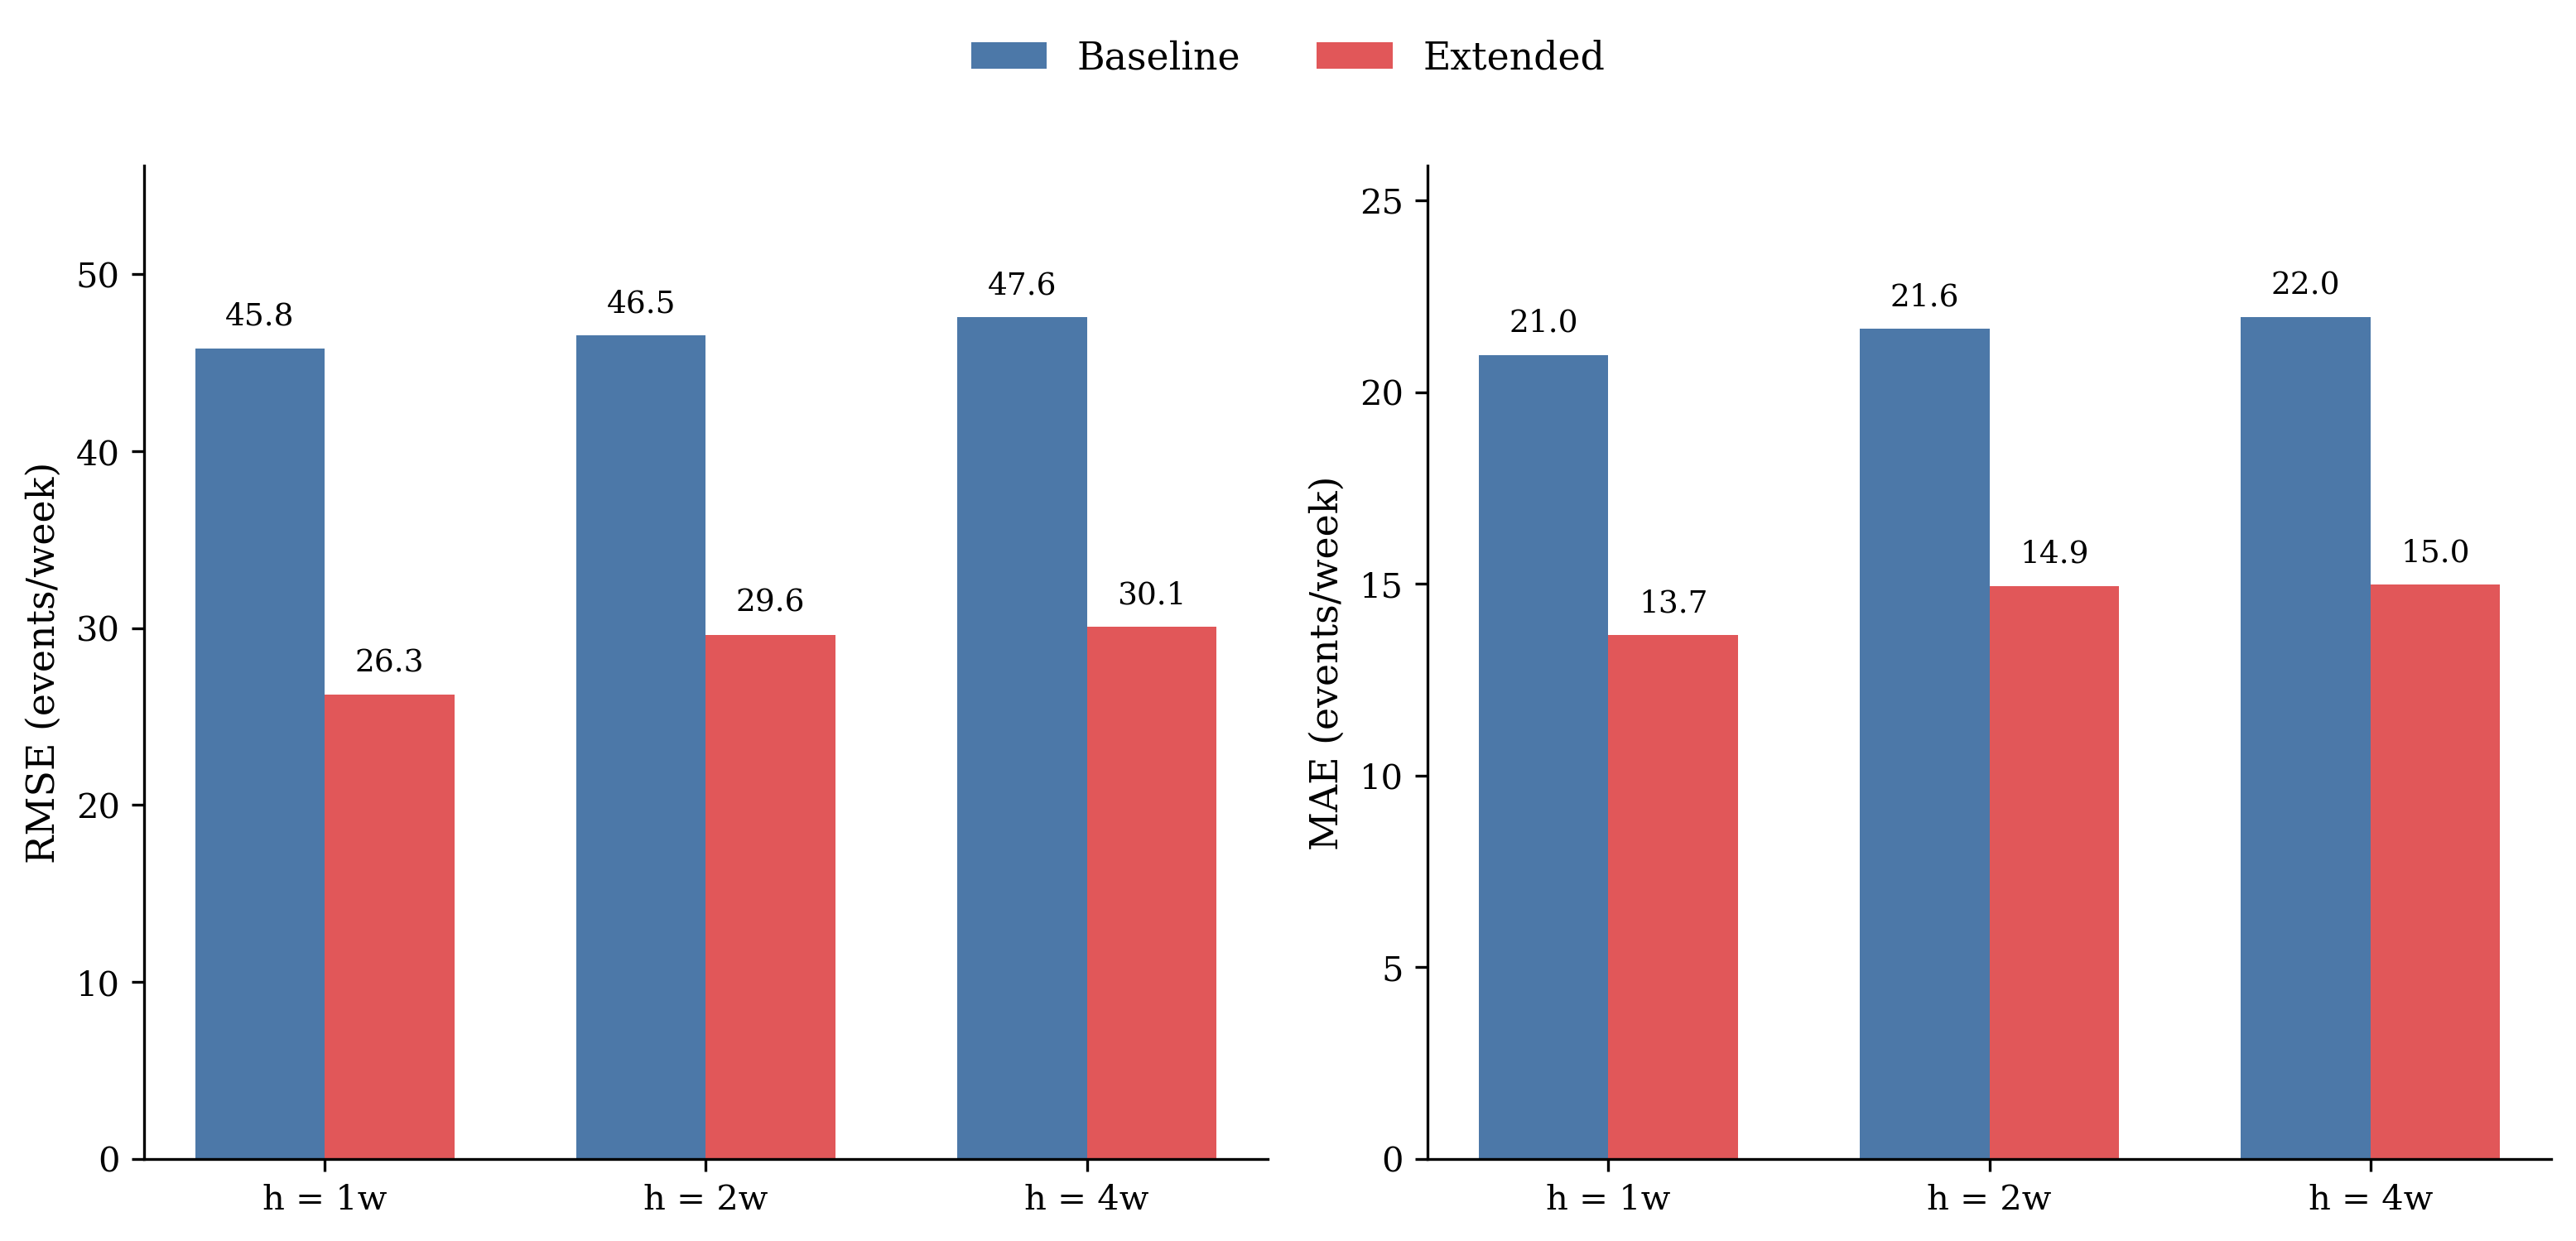

In [10]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(10.5, 4.8)
)

metrics = ["rmse", "mae"]
ylabels = [
    "RMSE (events/week)",
    "MAE (events/week)"
]

x = np.arange(len(HORIZONS))
width = 0.34

for ax, metric, ylabel in zip(axes, metrics, ylabels):

    baseline = [
        baseline_results[h]["test_metrics"][metric]
        for h in HORIZONS
    ]

    extended = [
        extended_results[h]["test_metrics"][metric]
        for h in HORIZONS
    ]

    bars1 = ax.bar(
        x - width/2,
        baseline,
        width,
        color=COLOR_BASE,
        label="Baseline"
    )

    bars2 = ax.bar(
        x + width/2,
        extended,
        width,
        color=COLOR_EXT,
        label="Extended"
    )

    # value labels
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + max(baseline + extended)*0.02,
                f"{height:.1f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    ax.set_xticks(x)
    ax.set_xticklabels([f"h = {h}w" for h in HORIZONS])

    ax.set_ylabel(ylabel)

    ax.set_ylim(
        0,
        max(baseline + extended)*1.18
    )

    ax.grid(axis="y")
    ax.grid(axis="x", visible=False)

# shared legend ABOVE plot
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=2
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    RESULTS_DIR / "figure2_pooled_metrics.png",
    bbox_inches="tight"
)

plt.show()

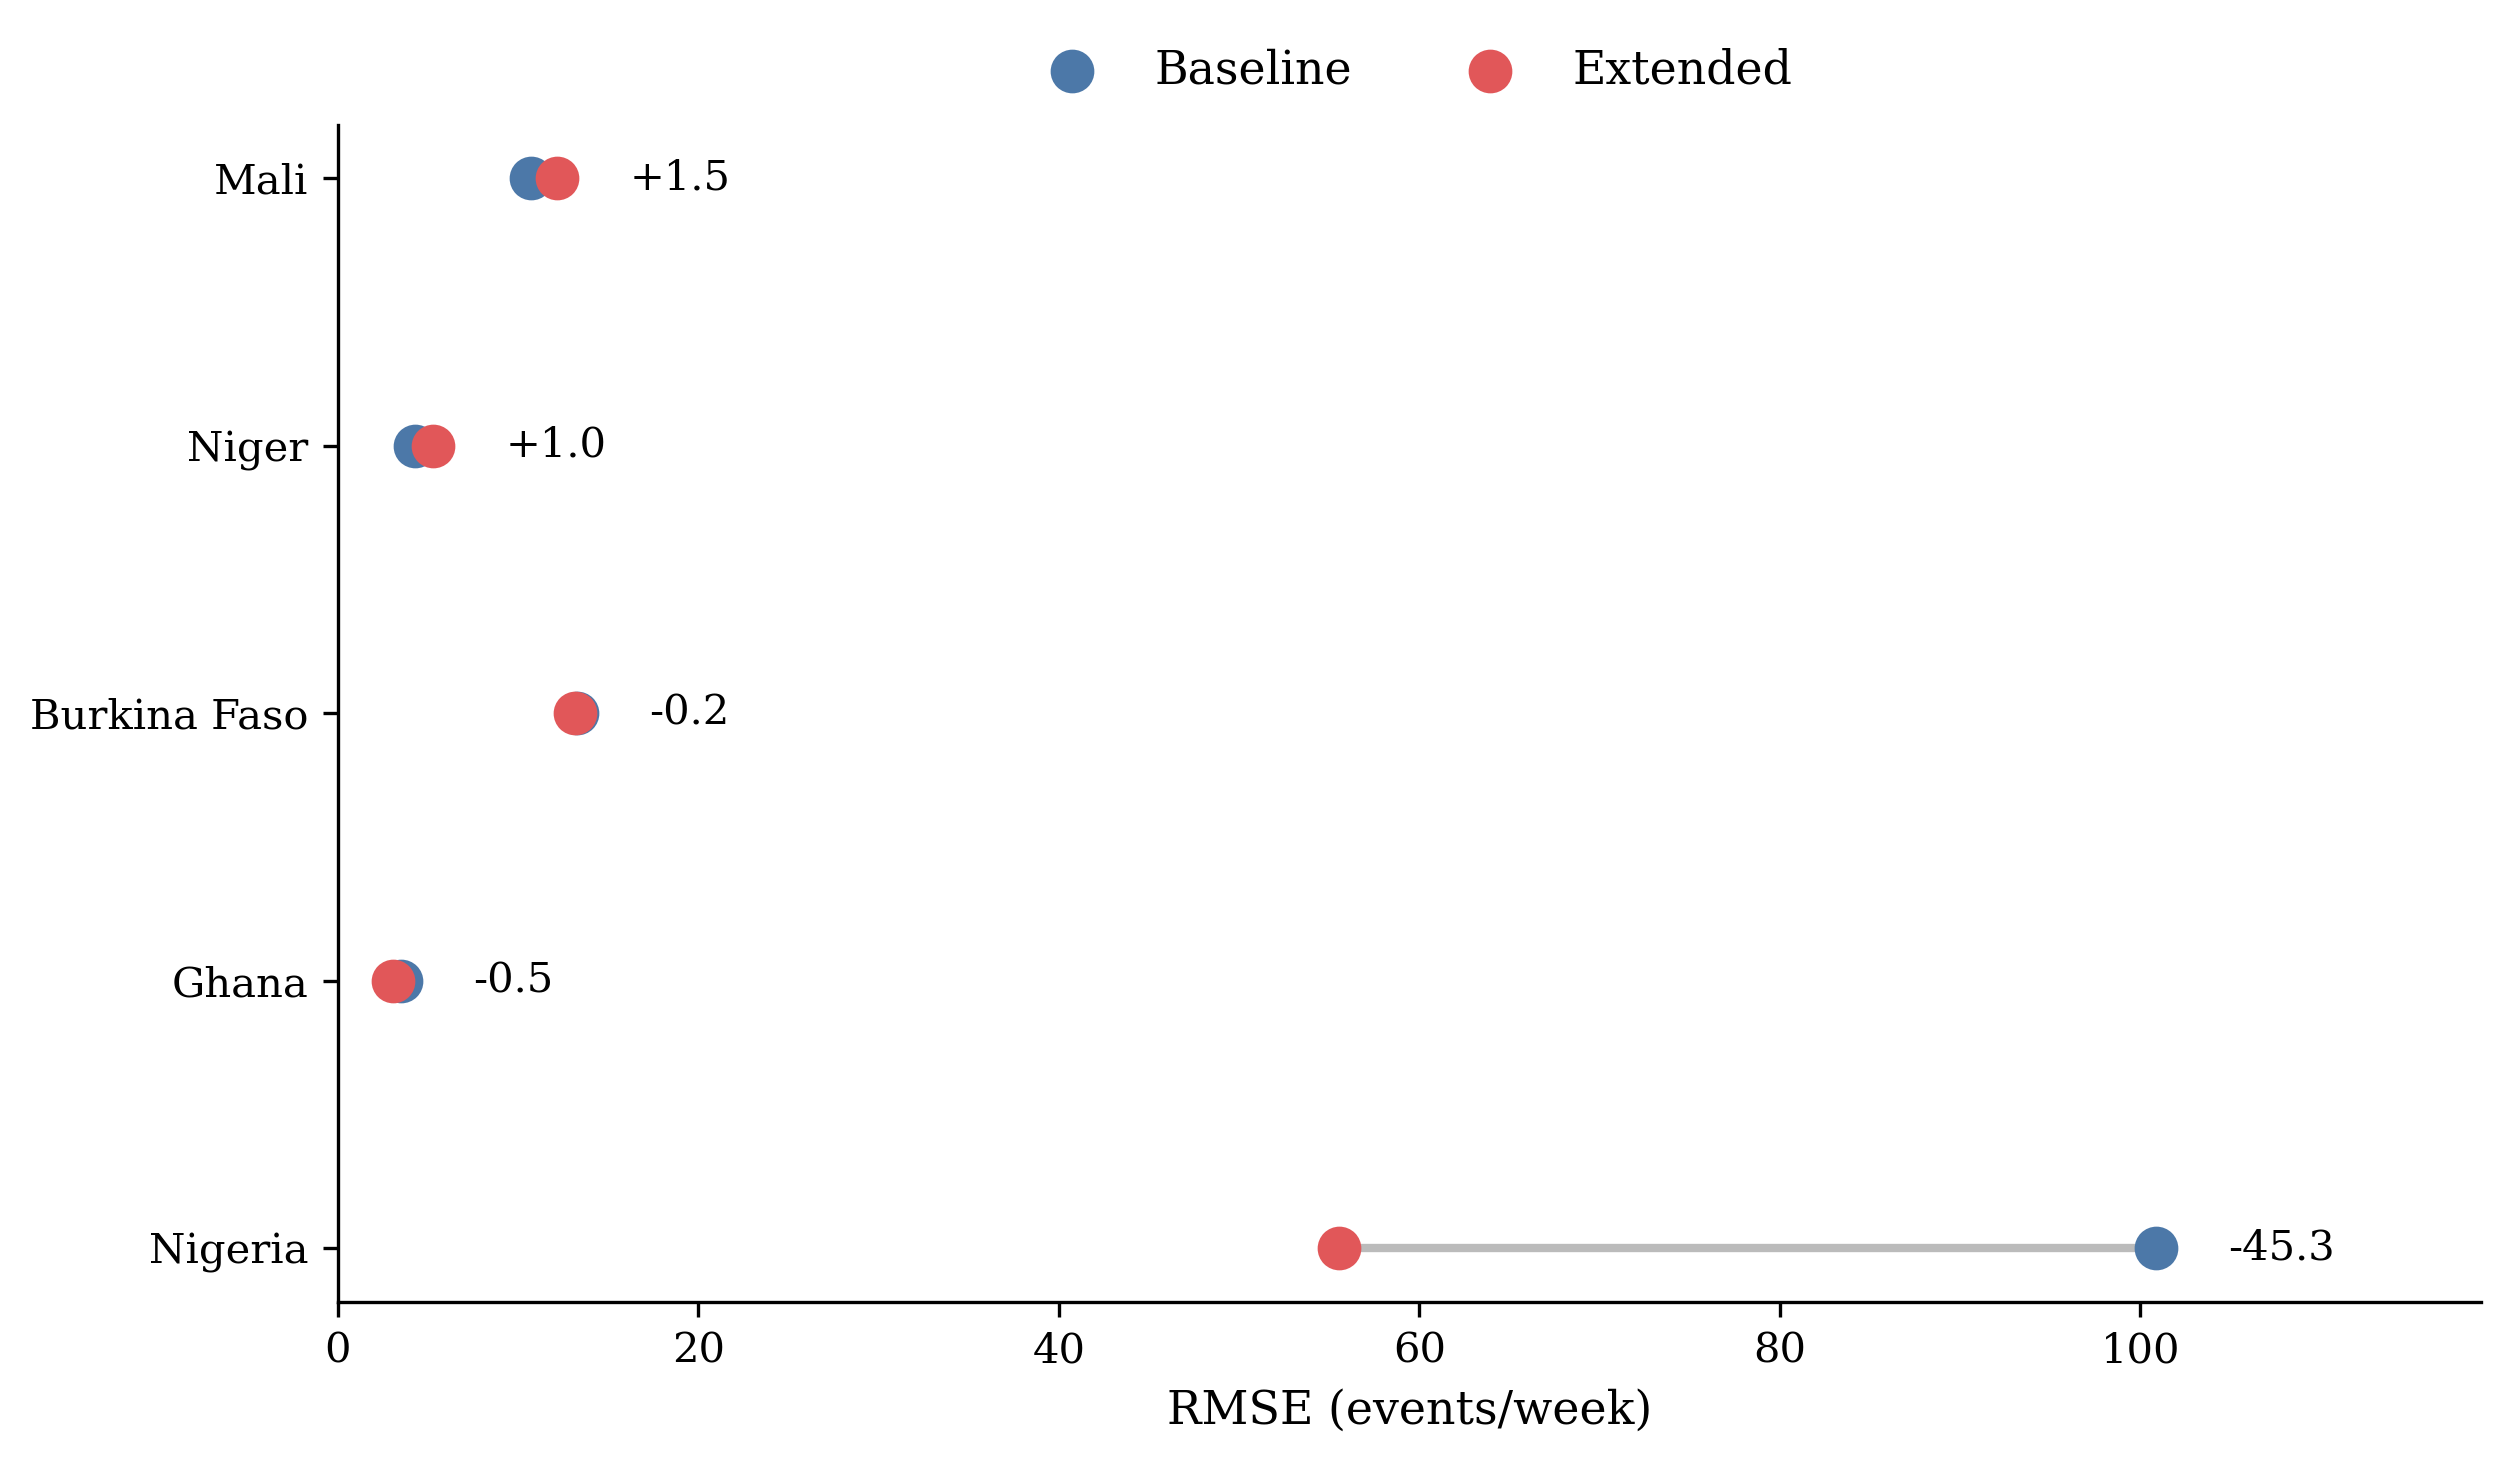

In [11]:
fig, ax = plt.subplots(
    figsize=(8.5, 5)
)

plot_df = (
    country_df
    .sort_values("delta_rmse")
    .reset_index(drop=True)
)

y = np.arange(len(plot_df))

# connecting lines
for i, row in plot_df.iterrows():

    ax.plot(
        [row["baseline_rmse"], row["extended_rmse"]],
        [i, i],
        color="#BBBBBB",
        lw=2,
        zorder=1
    )

# points
ax.scatter(
    plot_df["baseline_rmse"],
    y,
    s=90,
    color=COLOR_BASE,
    label="Baseline",
    zorder=3
)

ax.scatter(
    plot_df["extended_rmse"],
    y,
    s=90,
    color=COLOR_EXT,
    label="Extended",
    zorder=3
)

# delta labels
for i, row in plot_df.iterrows():

    rightmost = max(
        row["baseline_rmse"],
        row["extended_rmse"]
    )

    ax.text(
        rightmost + 4,
        i,
        f"{row['delta_rmse']:+.1f}",
        va="center",
        fontsize=10
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_df["country"])

ax.set_xlabel("RMSE (events/week)")

ax.grid(axis="x")
ax.grid(axis="y", visible=False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=2
)

# add space for labels
ax.set_xlim(
    0,
    max(plot_df["baseline_rmse"]) + 18
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "figure3_country_dumbbell.png",
    bbox_inches="tight"
)

plt.show()

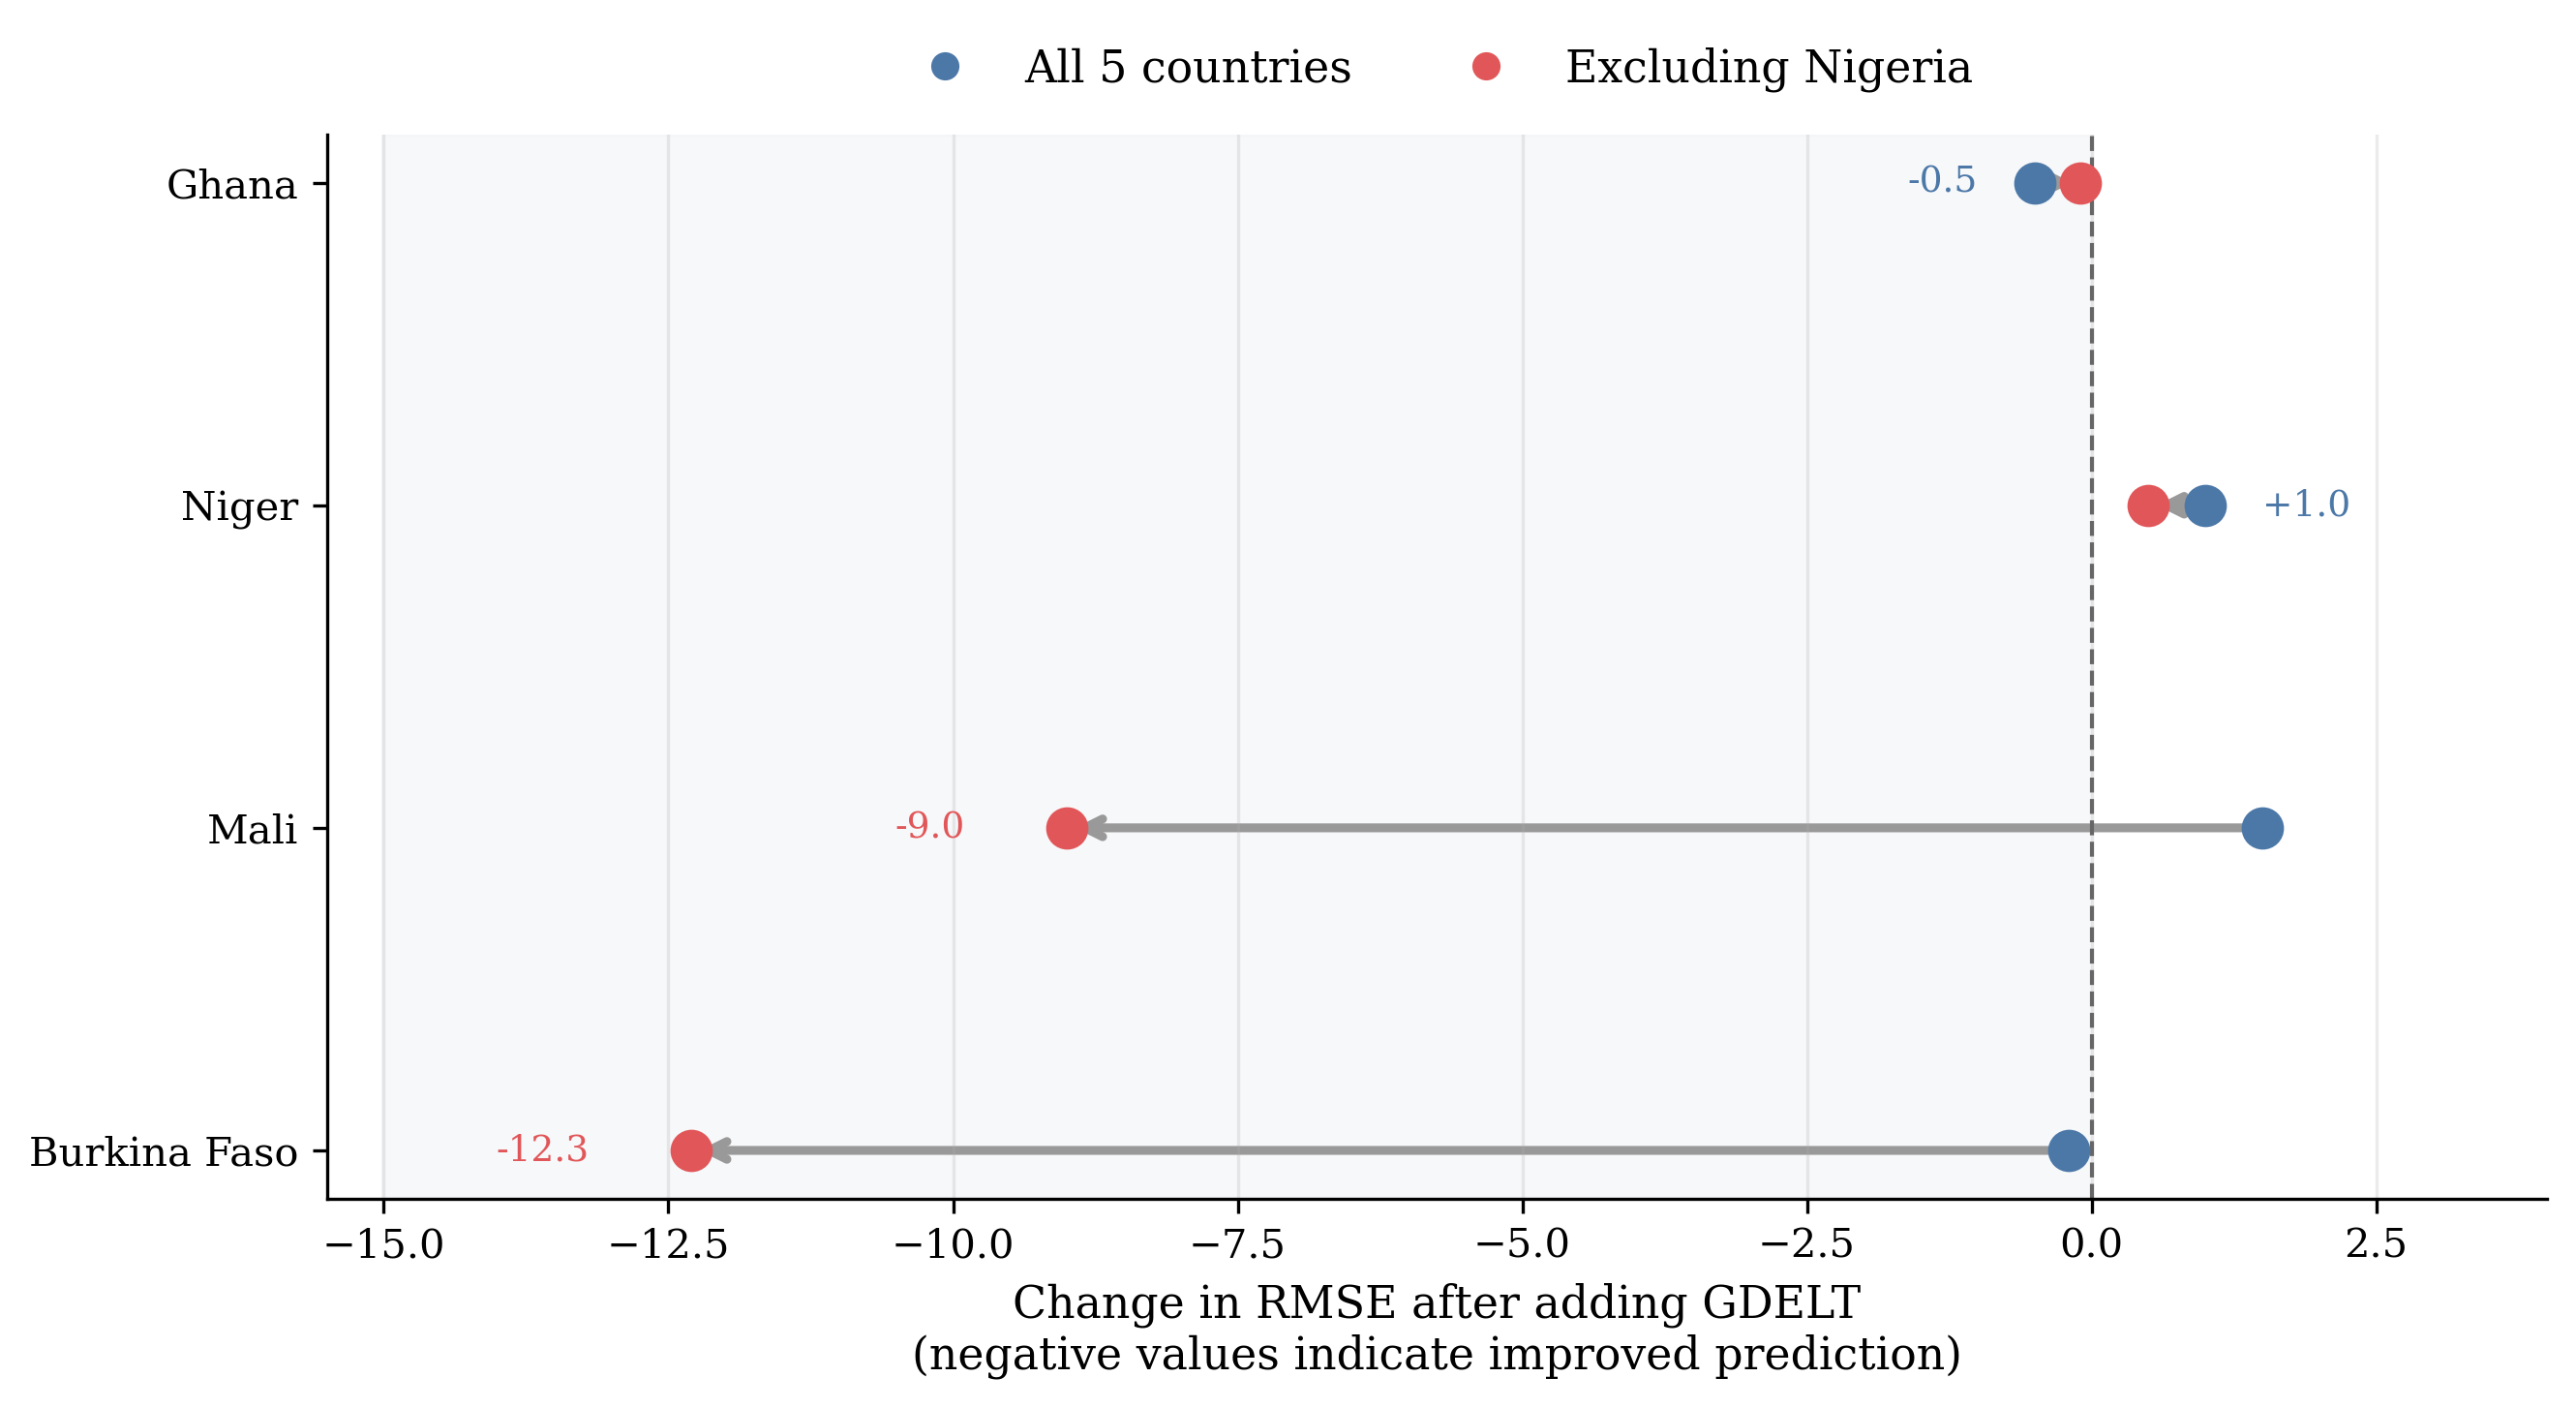

In [12]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

# DATA
countries = [
    "Burkina Faso",
    "Mali",
    "Niger",
    "Ghana"
]

full_sample = [-0.2, 1.5, 1.0, -0.5]
without_ng  = [-12.3, -9.0, 0.5, -0.1]

y = np.arange(len(countries))

# subtle improvement zone
ax.axvspan(
    -15,
    0,
    color="#F4F6F8",
    alpha=0.7,
    zorder=0
)

# zero reference line
ax.axvline(
    0,
    color="#666666",
    linestyle="--",
    lw=1
)

# arrows + points
for i in range(len(countries)):

    start = full_sample[i]
    end   = without_ng[i]

    # arrow
    ax.annotate(
        "",
        xy=(end, i),
        xytext=(start, i),
        arrowprops=dict(
            arrowstyle="->",
            lw=2.2,
            color="#999999"
        ),
        zorder=1
    )

    # starting point
    ax.scatter(
        start,
        i,
        s=90,
        color=COLOR_BASE,
        zorder=3
    )

    # ending point
    ax.scatter(
        end,
        i,
        s=90,
        color=COLOR_EXT,
        zorder=3
    )

    # ── ONLY ONE LABEL PER ARROW ──────────────────────────────
    # label whichever point is more extreme

    if abs(end) > abs(start):
        label_x = end
        label_color = COLOR_EXT
        ha = "right" if end < 0 else "left"

        # larger offset avoids overlap with axis
        offset = -0.9 if end < 0 else 0.5

    else:
        label_x = start
        label_color = COLOR_BASE
        ha = "right" if start < 0 else "left"
        offset = -0.5 if start < 0 else 0.5

    ax.text(
        label_x + offset,
        i,
        f"{label_x:+.1f}",
        fontsize=9,
        color=label_color,
        ha=ha,
        va="center"
    )

# axis labels
ax.set_yticks(y)
ax.set_yticklabels(countries)

ax.set_xlabel(
    "Change in RMSE after adding GDELT\n"
    "(negative values indicate improved prediction)"
)

# limits
ax.set_xlim(-15.5, 4)

# grid
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

# custom legend
from matplotlib.lines import Line2D

legend_elements = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='All 5 countries',
        markerfacecolor=COLOR_BASE,
        markersize=8
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Excluding Nigeria',
        markerfacecolor=COLOR_EXT,
        markersize=8
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=2
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "figure4_transition_plot.png",
    bbox_inches="tight"
)

plt.show()

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

COLOR_BASE = "#2E86AB"
COLOR_EXT  = "#E84855"
COLOR_OBS  = "#A8DADC"
COLOR_AMB  = "#F4A261"

mpl.rcParams.update({
    "font.size":        10,
    "axes.titlesize":   12,
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#EEEEEE",
    "legend.frameon":   False,
    "figure.dpi":       150,
})

print("Style settings applied.")

Style settings applied.


In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({

    # Font
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],

    # Sizes
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Clean axes
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Grid
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.7,

    # Figure quality
    "figure.dpi": 300,
    "savefig.dpi": 300,

    # PDF font embedding
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

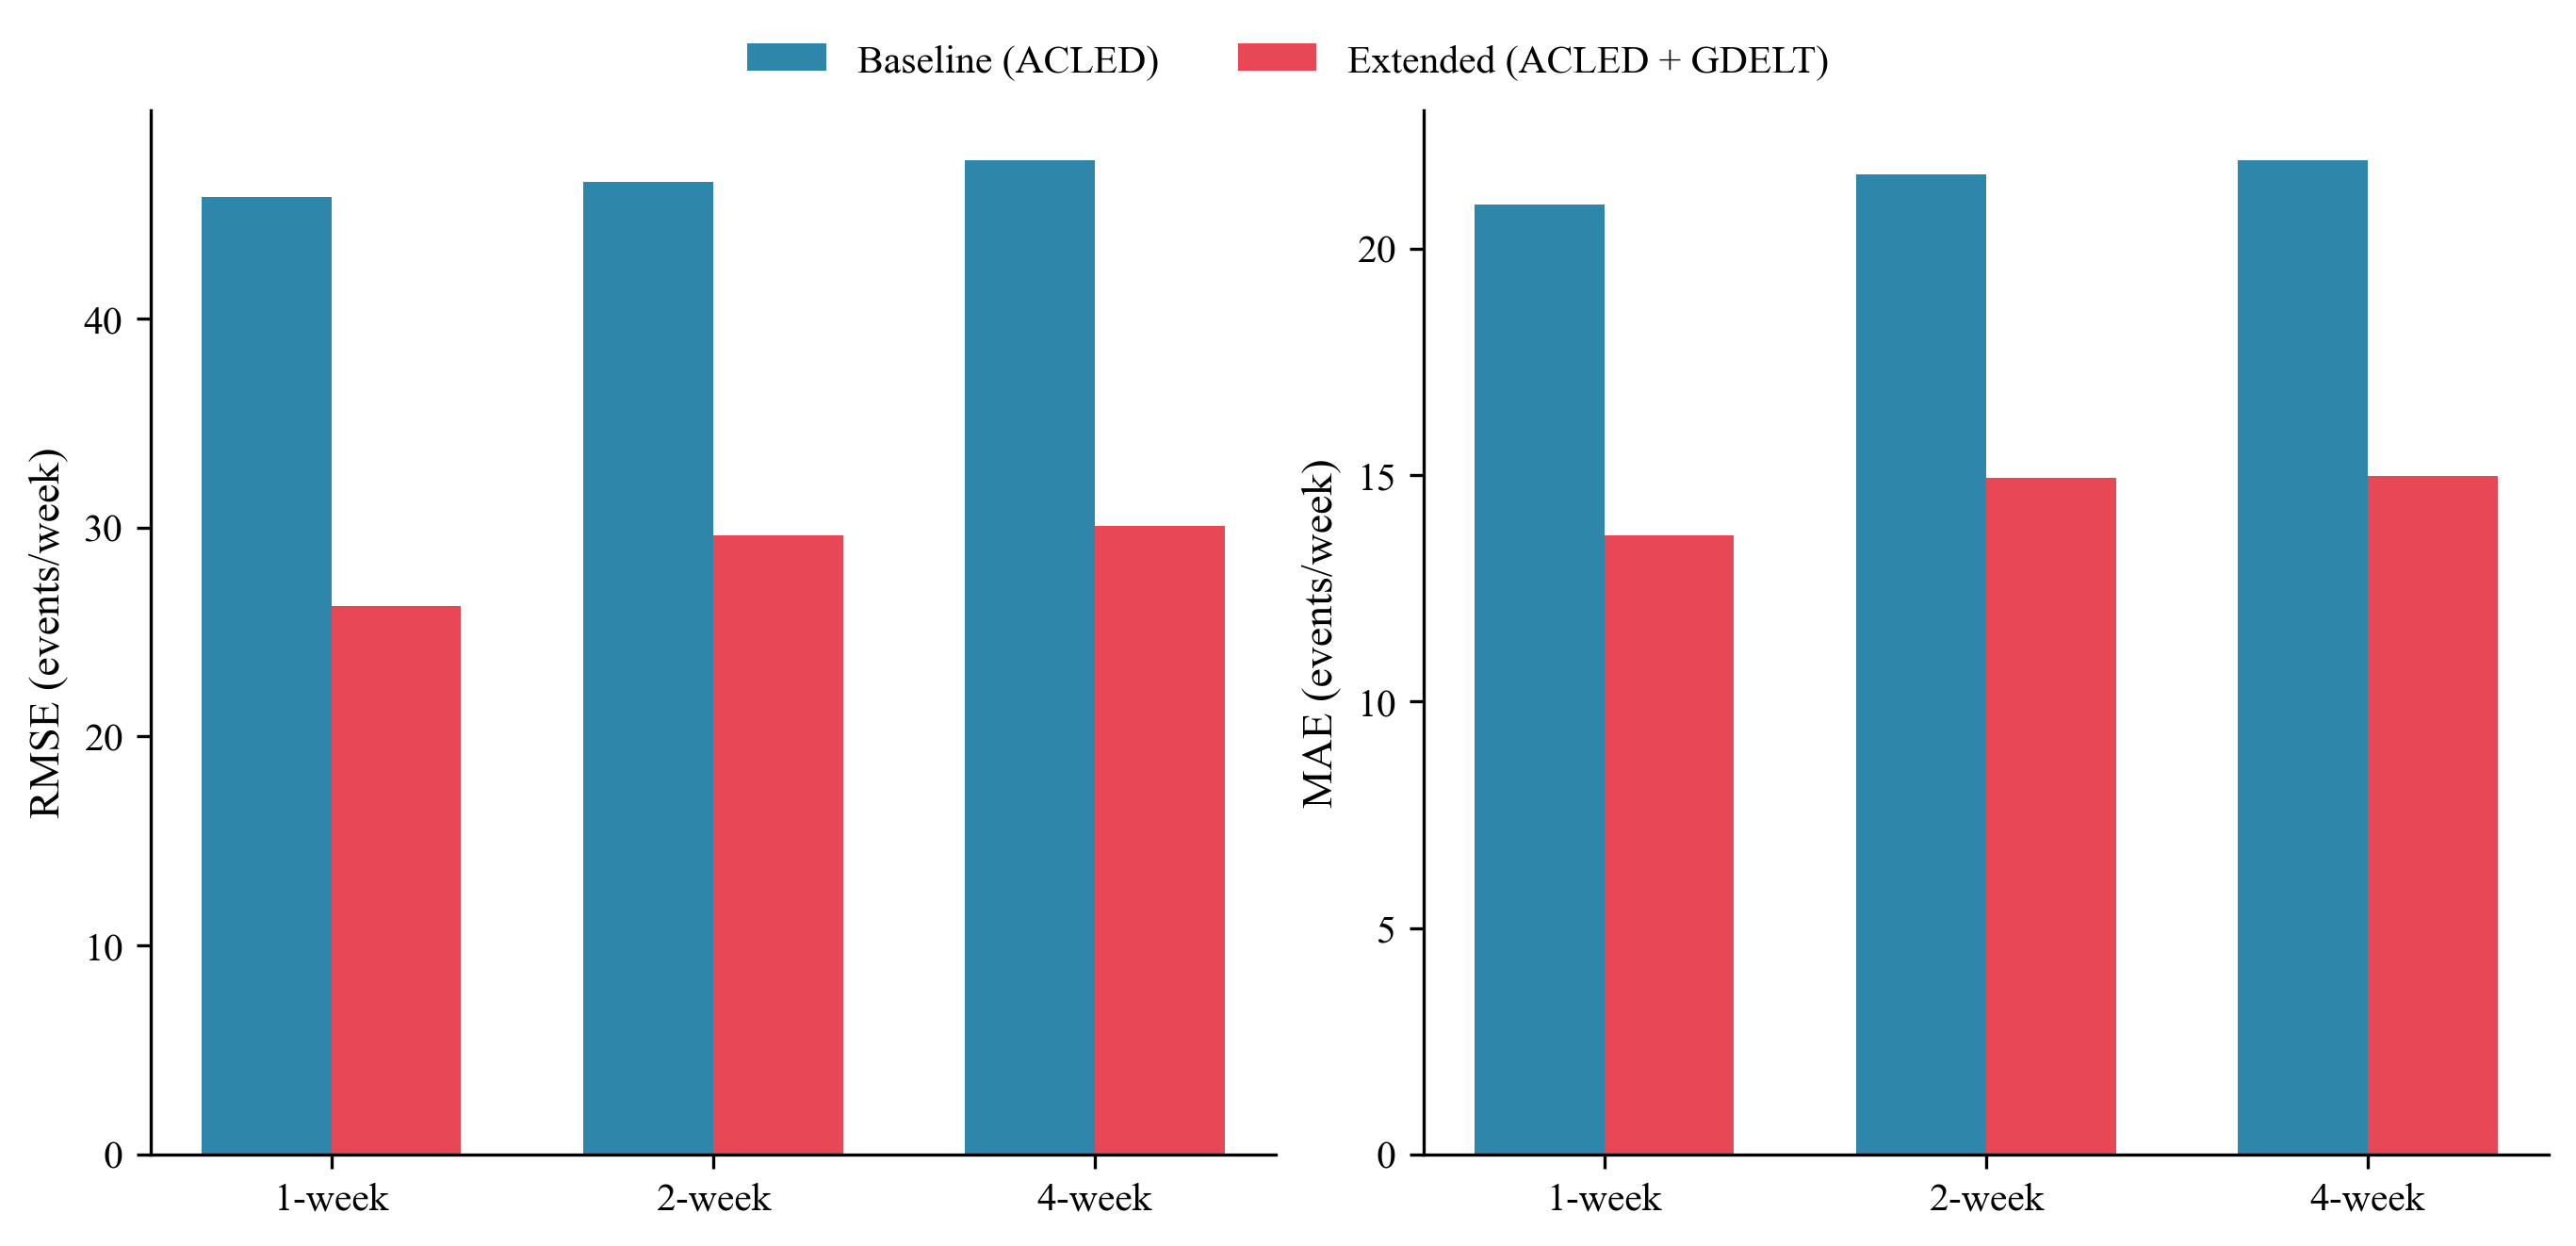

In [15]:
# -----------------------------------
# FIGURE 2 — RMSE & MAE COMPARISON
# -----------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(9, 4),
    constrained_layout=True
)

metrics  = ["rmse", "mae"]
ylabels  = ["RMSE (events/week)", "MAE (events/week)"]

x = np.arange(len(HORIZONS))
width = 0.34

for ax, metric, ylabel in zip(axes, metrics, ylabels):

    baseline_vals = [
        baseline_results[h]["test_metrics"][metric]
        for h in HORIZONS
    ]

    extended_vals = [
        extended_results[h]["test_metrics"][metric]
        for h in HORIZONS
    ]

    ax.bar(
        x - width/2,
        baseline_vals,
        width,
        color=COLOR_BASE,
        label="Baseline"
    )

    ax.bar(
        x + width/2,
        extended_vals,
        width,
        color=COLOR_EXT,
        label="Extended"
    )

    ax.set_xticks(x)
    ax.set_xticklabels([f"{h}-week" for h in HORIZONS])

    ax.set_ylabel(ylabel)

    ax.grid(axis="y")
    ax.grid(axis="x", visible=False)

# Single shared legend
fig.legend(
    ["Baseline (ACLED)", "Extended (ACLED + GDELT)"],
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.08)
)

plt.savefig(
    RESULTS_DIR / "figure2_main_results.pdf"
)

plt.show()

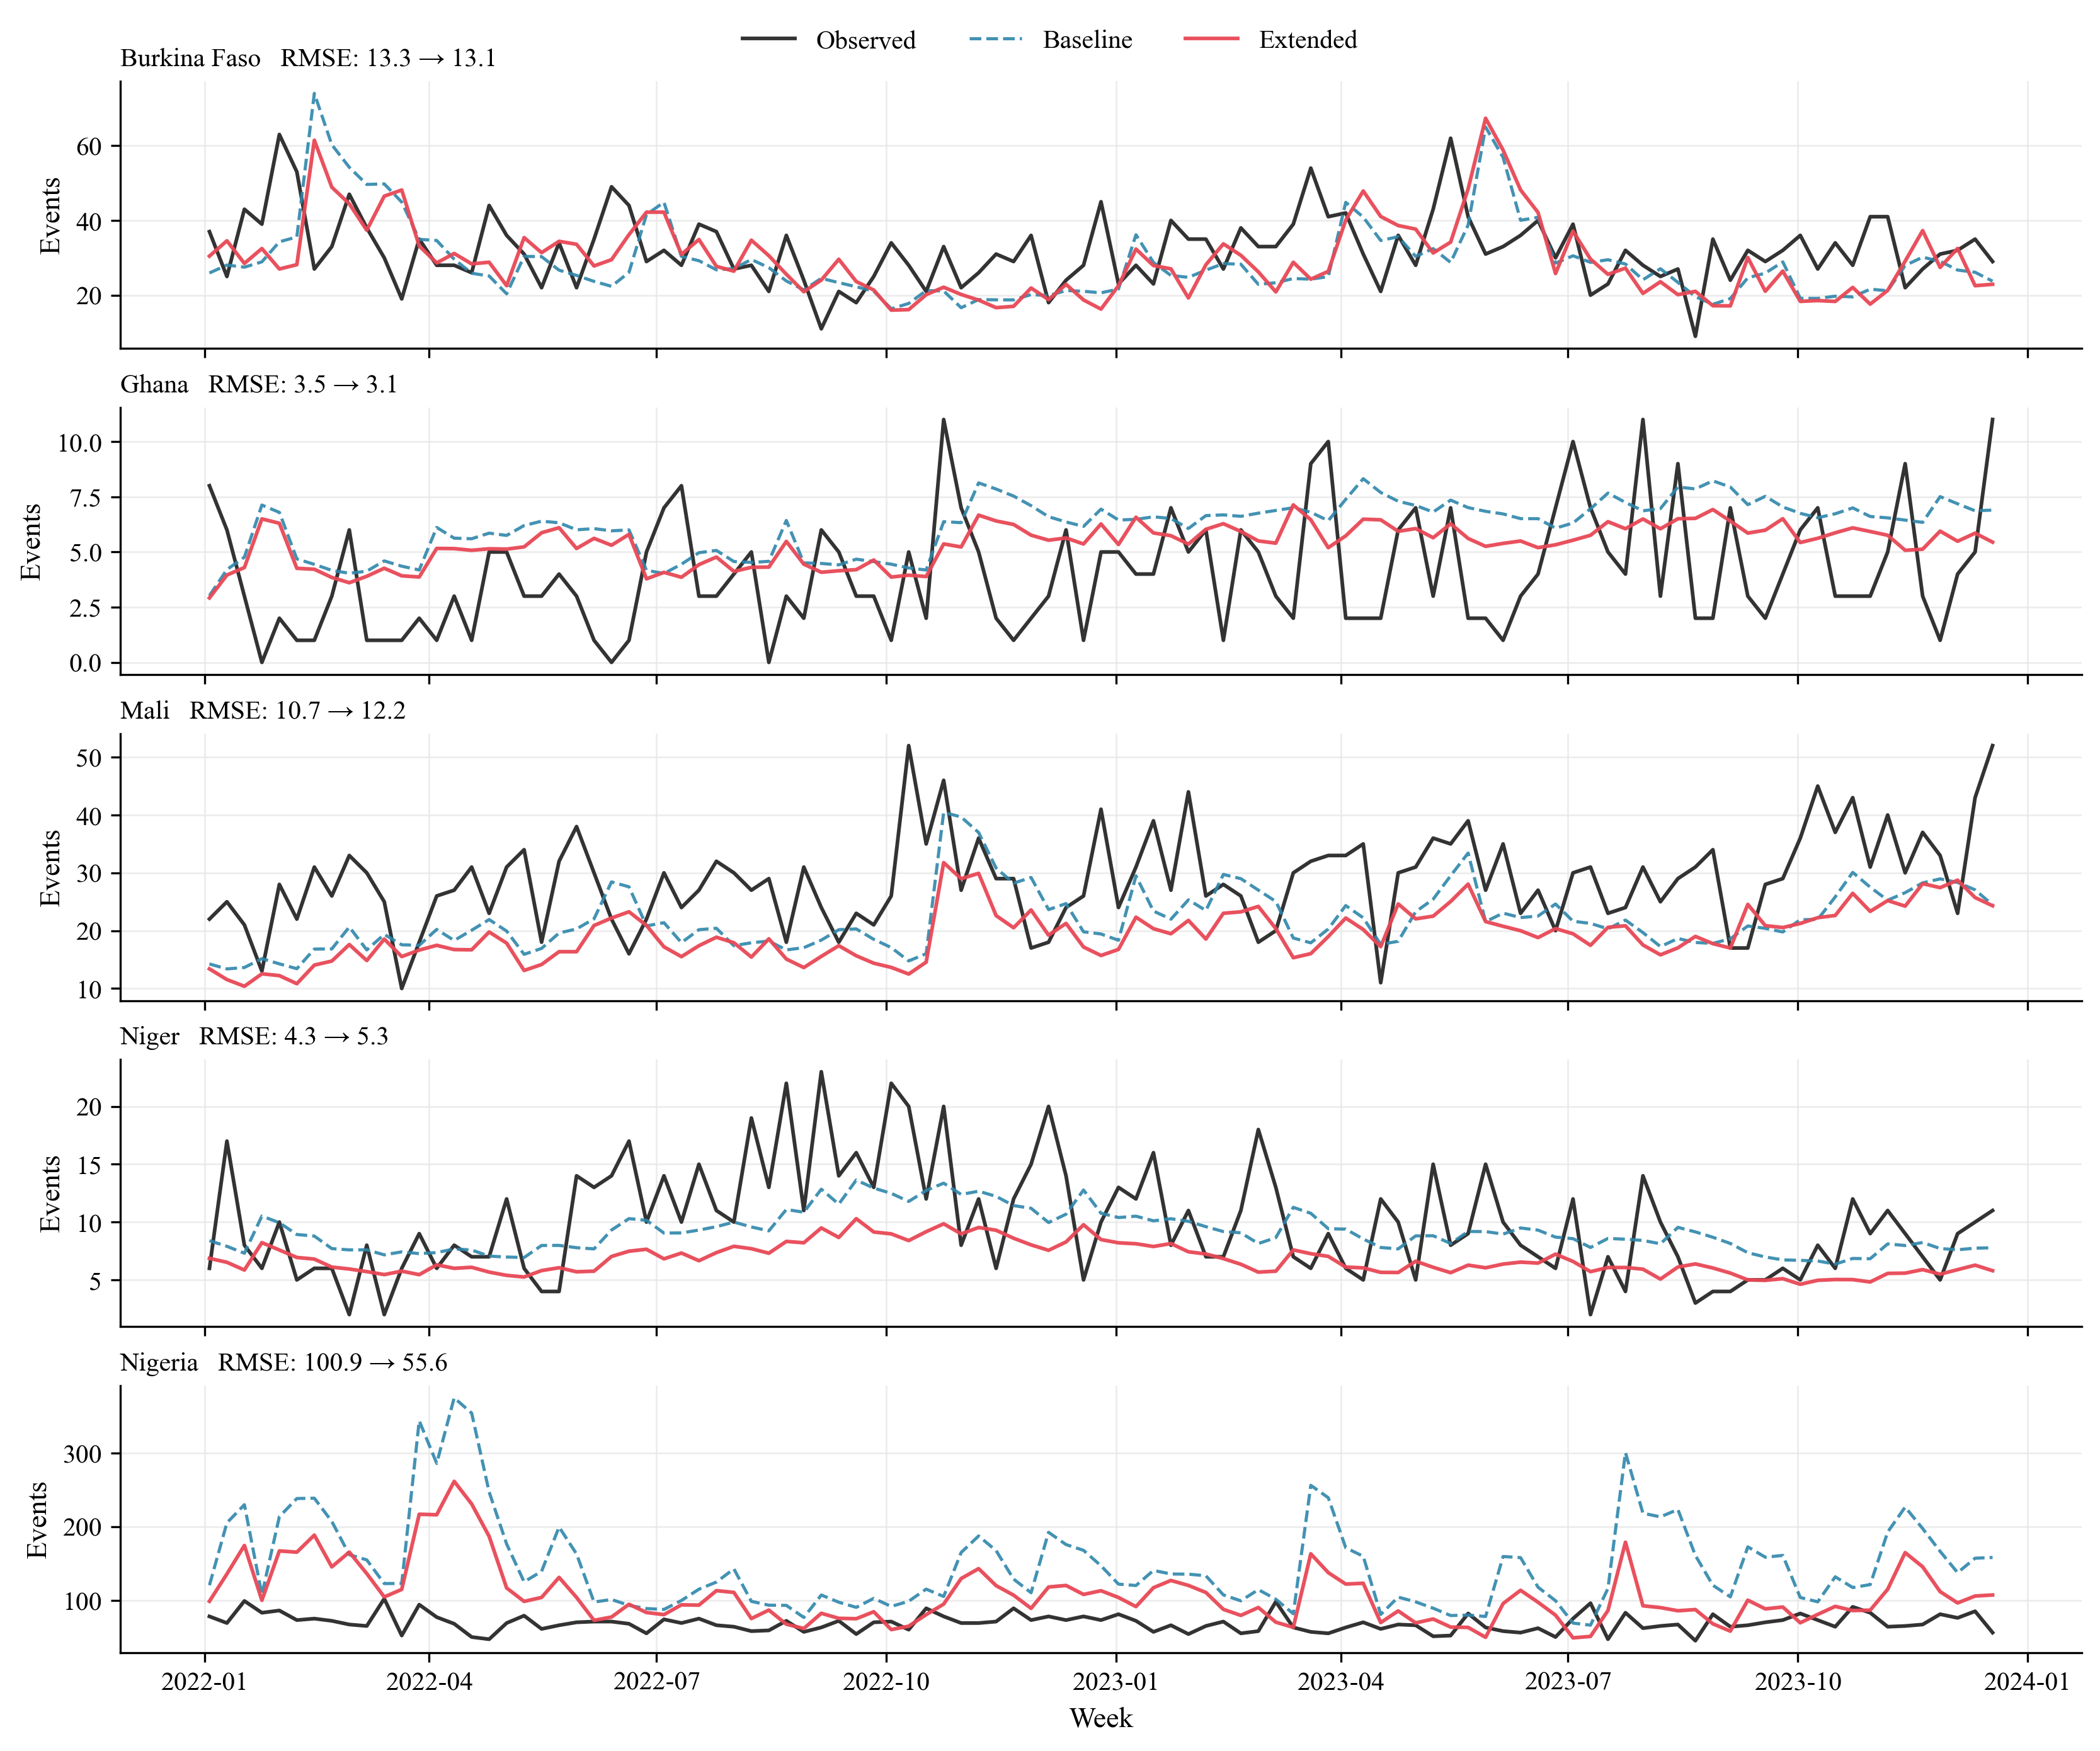

In [16]:
# ── FIGURE 4: Observed vs predicted ───────────────────────────

TARGET_COUNTRIES_SORTED = [
    "Burkina Faso",
    "Ghana",
    "Mali",
    "Niger",
    "Nigeria"
]

fig, axes = plt.subplots(
    len(TARGET_COUNTRIES_SORTED),
    1,
    figsize=(11, 9),
    sharex=True,
    constrained_layout=True
)

for ax, country in zip(axes, TARGET_COUNTRIES_SORTED):

    sub = (
        test_meta[test_meta["COUNTRY"] == country]
        .sort_values("week_start")
    )

    weeks = sub["week_start"]

    # Observed
    ax.plot(
        weeks,
        sub["y_true"],
        color="#333333",
        lw=1.4,
        label="Observed"
    )

    # Baseline
    ax.plot(
        weeks,
        sub["y_pred_base"],
        color=COLOR_BASE,
        lw=1.2,
        ls="--",
        alpha=0.9,
        label="Baseline"
    )

    # Extended
    ax.plot(
        weeks,
        sub["y_pred_ext"],
        color=COLOR_EXT,
        lw=1.4,
        alpha=0.95,
        label="Extended"
    )

    base_r = np.sqrt(np.mean(
        (sub["y_true"] - sub["y_pred_base"])**2
    ))

    ext_r = np.sqrt(np.mean(
        (sub["y_true"] - sub["y_pred_ext"])**2
    ))

    ax.set_title(
        f"{country}   RMSE: {base_r:.1f} → {ext_r:.1f}",
        fontsize=10,
        loc="left"
    )

    ax.set_ylabel("Events")

# One shared legend only
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

axes[-1].set_xlabel("Week")

plt.savefig(
    RESULTS_DIR / "figure4_predictions.pdf",
    bbox_inches="tight"
)

plt.show()

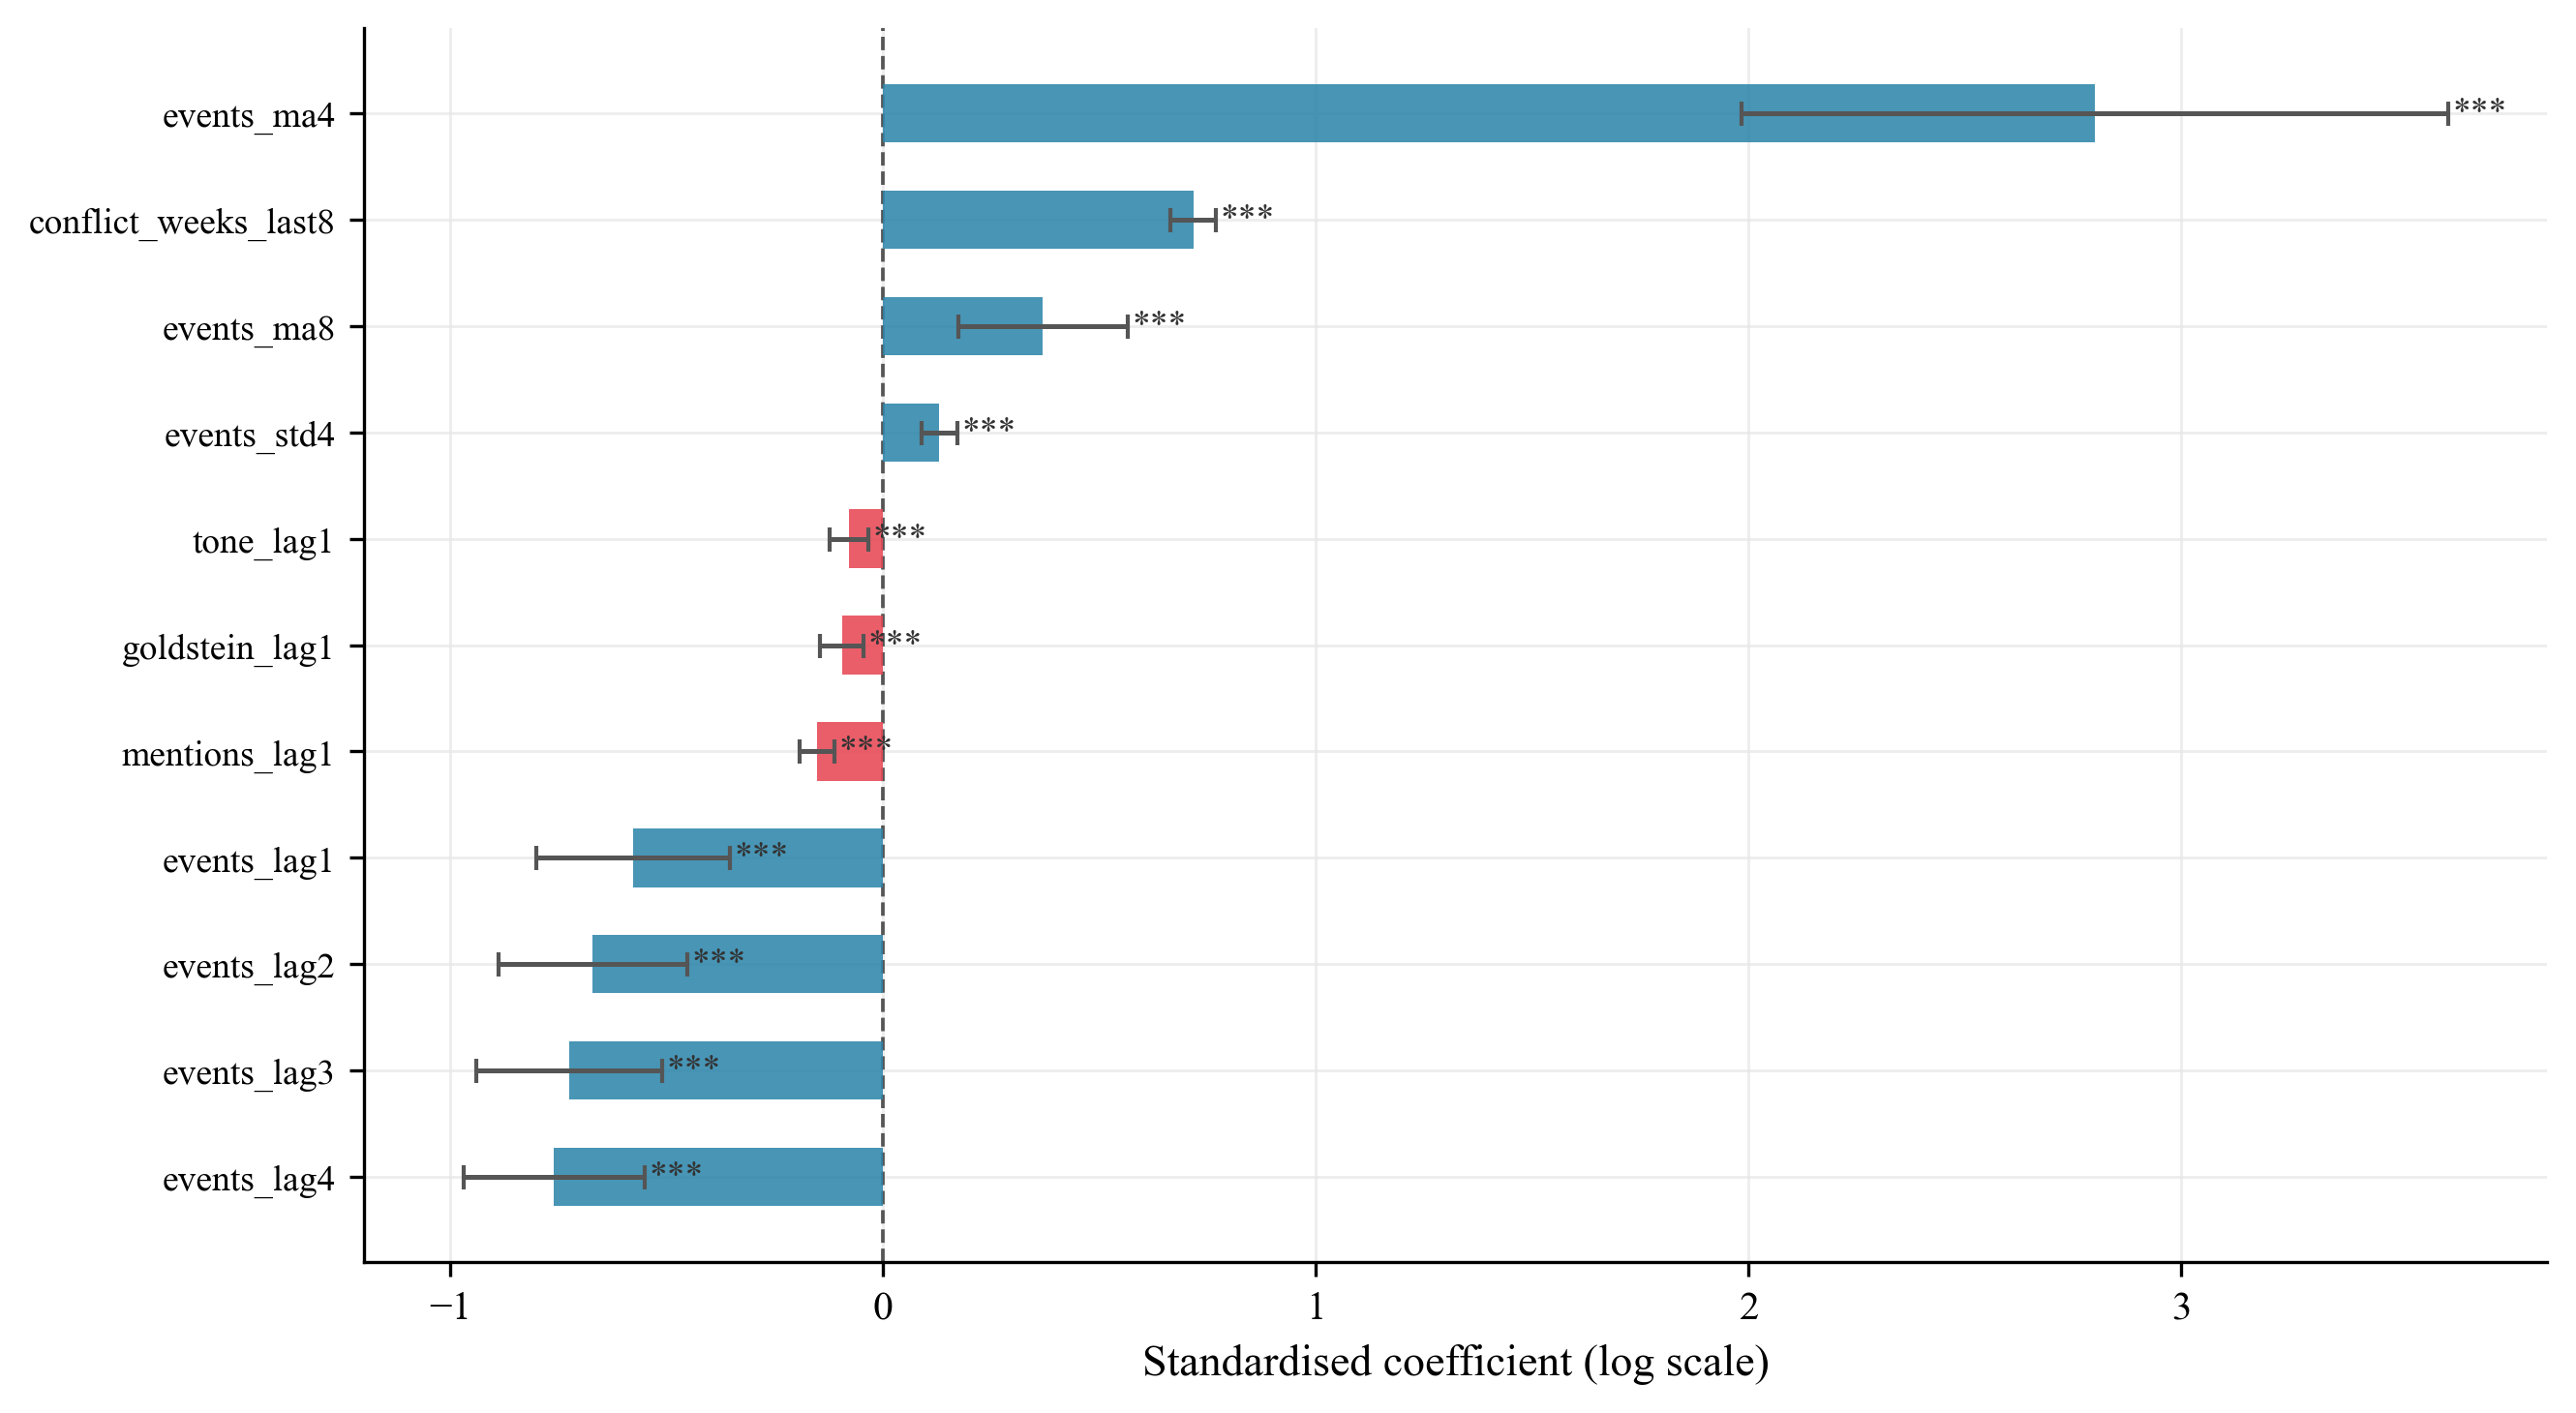

In [18]:
# ── GRAPH 6: Coefficient forest plot — extended model h=1 ─────
coef_df = build_coef_table(extended_results[1]["result"]).sort_values("Coefficient")

fig, ax  = plt.subplots(figsize=(9, 5))
y_pos    = np.arange(len(coef_df))
colors   = [COLOR_EXT if idx in GDELT_PREDICTORS
            else COLOR_BASE for idx in coef_df.index]

ax.barh(y_pos, coef_df["Coefficient"],
        xerr=1.96 * coef_df["Std. Error"],
        color=colors, alpha=0.88, height=0.55,
        error_kw={"elinewidth": 1.2, "capsize": 3, "ecolor": "#555555"},
        zorder=3)

ax.axvline(0, color="#555555", lw=0.9, ls="--")
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_df.index, fontsize=9)
ax.set_xlabel("Standardised coefficient (log scale)")

# Significance stars
for i, (idx, row) in enumerate(coef_df.iterrows()):
    sig = ("***" if row["p-value"] < 0.001
           else "**"  if row["p-value"] < 0.01
           else "*"   if row["p-value"] < 0.05
           else "")
    if sig:
        xpos = row["Coefficient"] + 1.96 * row["Std. Error"] + 0.01
        ax.text(xpos, i, sig, va="center", fontsize=9, color="#333333")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "graph6_coef_forest.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 8b. Time series by country — both models (h = 1)

Shaded area = observed. Dashed red = baseline. Solid orange = extended. Shows directly where GDELT variables add value relative to conflict history alone.

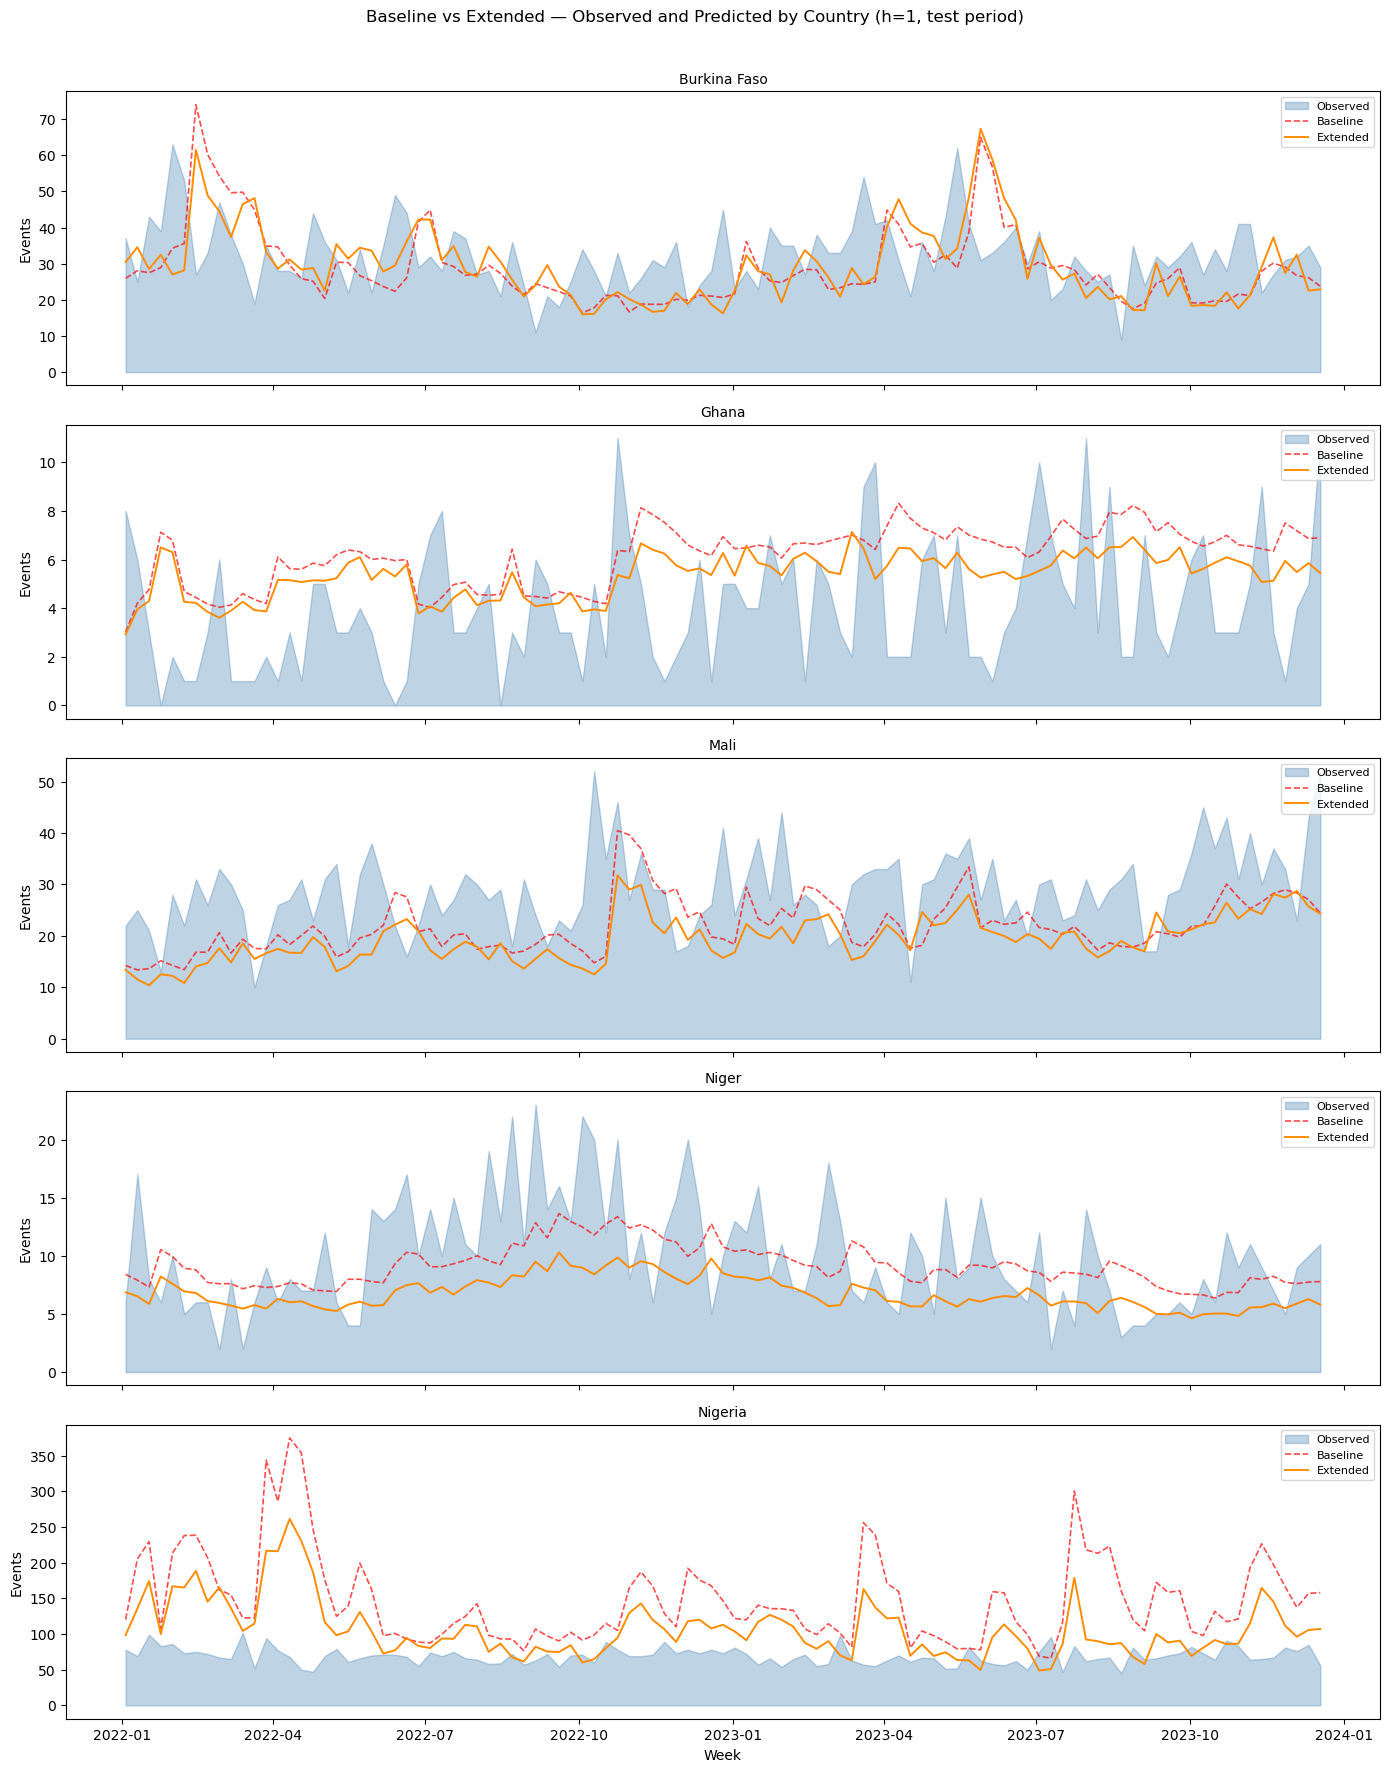

In [10]:
TARGET_COUNTRIES = sorted(panel["COUNTRY"].unique())
fig, axes = plt.subplots(len(TARGET_COUNTRIES), 1,
                          figsize=(14, 3.5 * len(TARGET_COUNTRIES)), sharex=True)

for ax, country in zip(axes, TARGET_COUNTRIES):
    sub = test_meta[test_meta["COUNTRY"] == country].sort_values("week_start")
    ax.fill_between(sub["week_start"], sub["y_true"],
                    alpha=0.35, color="steelblue", label="Observed")
    ax.plot(sub["week_start"], sub["y_pred_base"],
            color="red", lw=1.2, ls="--", alpha=0.7, label="Baseline")
    ax.plot(sub["week_start"], sub["y_pred_ext"],
            color="darkorange", lw=1.4, label="Extended")
    ax.set_title(country, fontsize=10)
    ax.set_ylabel("Events")
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Week")
plt.suptitle("Baseline vs Extended — Observed and Predicted by Country (h=1, test period)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "comparison_timeseries_h1.png", dpi=150, bbox_inches="tight")
plt.show()

### 8c. Country-level RMSE comparison

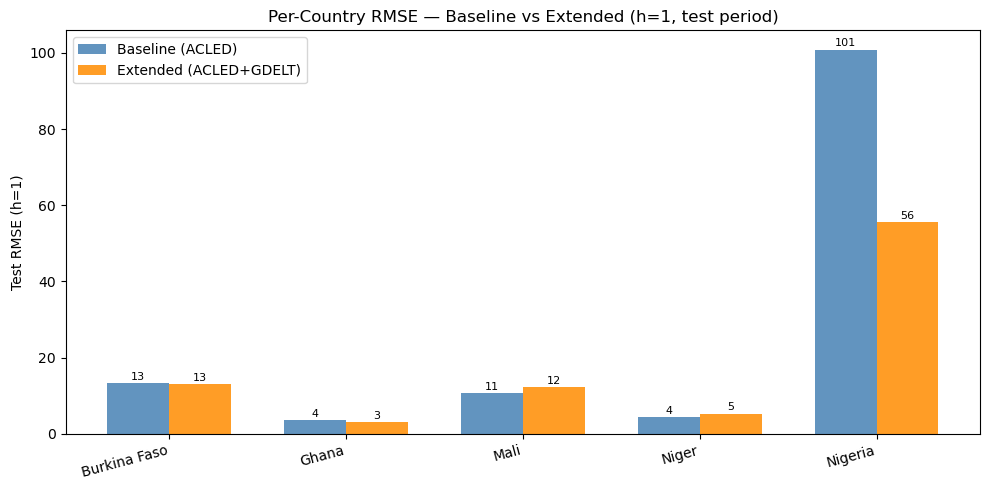

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
countries = country_df["country"].tolist()
x         = np.arange(len(countries))
width     = 0.35

b1 = ax.bar(x - width/2, country_df["baseline_rmse"], width,
            label="Baseline (ACLED)", color="steelblue", alpha=0.85)
b2 = ax.bar(x + width/2, country_df["extended_rmse"], width,
            label="Extended (ACLED+GDELT)", color="darkorange", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(countries, rotation=15, ha="right")
ax.set_ylabel("Test RMSE (h=1)")
ax.set_title("Per-Country RMSE — Baseline vs Extended (h=1, test period)")
ax.legend()

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "country_rmse_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 8d. GDELT coefficient plot (h = 1)

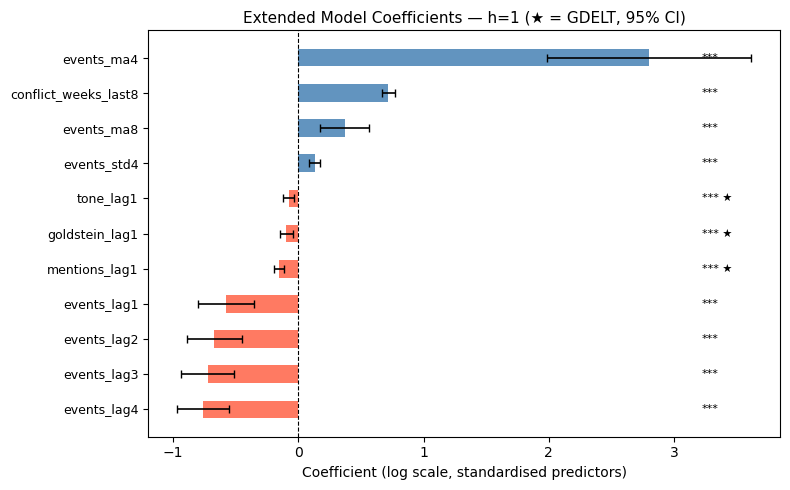

In [12]:
coef_all = build_coef_table(extended_results[1]["result"]).sort_values("Coefficient")
fig, ax  = plt.subplots(figsize=(8, 5))
y_pos    = np.arange(len(coef_all))

ax.barh(y_pos, coef_all["Coefficient"],
        xerr=1.96 * coef_all["Std. Error"],
        color=["tomato" if c < 0 else "steelblue" for c in coef_all["Coefficient"]],
        error_kw={"elinewidth": 1.2, "capsize": 3}, height=0.5, alpha=0.85)

for i, (idx, row) in enumerate(coef_all.iterrows()):
    marker = " ★" if idx in GDELT_PREDICTORS else ""
    sig    = ("***" if row["p-value"]<0.001 else "**" if row["p-value"]<0.01
              else "*" if row["p-value"]<0.05 else "(ns)")
    ax.text(coef_all["Coefficient"].abs().max() * 1.15,
            i, sig + marker, va="center", fontsize=8)

ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(y_pos); ax.set_yticklabels(coef_all.index, fontsize=9)
ax.set_xlabel("Coefficient (log scale, standardised predictors)")
ax.set_title("Extended Model Coefficients — h=1 (★ = GDELT, 95% CI)", fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "extended_coef_plot_h1.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Save All Results

In [13]:
rows = []
for h in HORIZONS:
    for ml, rd in [("baseline", baseline_results), ("extended", extended_results)]:
        for split in ["train", "test"]:
            row = {"model": ml, "horizon": h, "split": split}
            row.update(rd[h][f"{split}_metrics"])
            rows.append(row)
        pd.DataFrame({
            "y_observed":  np.array(rd[h]["y_test"]),
            "y_predicted": rd[h]["y_pred_test"],
        }).to_csv(RESULTS_DIR / f"{ml}_predictions_h{h}.csv", index=False)

all_metrics = pd.DataFrame(rows)
all_metrics.to_csv(RESULTS_DIR / "all_metrics.csv", index=False)
print(all_metrics.to_string(index=False))
print(f"\nAll outputs saved to: {RESULTS_DIR}")

   model  horizon split    rmse     mae
baseline        1 train 15.7613  6.2222
baseline        1  test 45.8283 20.9736
extended        1 train 11.8979  5.3171
extended        1  test 26.2516 13.6682
baseline        2 train 16.5335  6.4182
baseline        2  test 46.5422 21.6484
extended        2 train 12.8307  5.5564
extended        2  test 29.6270 14.9482
baseline        4 train 16.8984  6.6896
baseline        4  test 47.5835 21.9577
extended        4 train 13.0650  5.7570
extended        4  test 30.0931 14.9763

All outputs saved to: C:\Users\faiza\Documents\Uni\Year 3\Thesis\Results\extended
